In [1]:
# Step 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Step 2: Load the data
iris = load_iris()
X = iris.data  # Features: sepal length, sepal width, petal length, petal width
y = iris.target  # Target: 0=setosa, 1=versicolor, 2=virginica

# Step 3: Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 4: Create and train the model
model = DecisionTreeClassifier()
model.fit(X_train, y_train)  # This is where the learning happens!

# Step 5: Make predictions and evaluate
predictions = model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)
print(f"Model accuracy: {accuracy * 100:.2f}%")

Model accuracy: 100.00%


In [2]:
# Load the Iris dataset as a pandas DataFrame
iris_df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
iris_df['target'] = iris.target
iris_df['target_name'] = iris_df['target'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

# Explore the data
print("First 5 rows:")
print(iris_df.head())

print("\nDataset info:")
print(iris_df.info())

print("\nStatistical summary:")
print(iris_df.describe())

print("\nClass distribution:")
print(iris_df['target_name'].value_counts())

First 5 rows:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target target_name  
0       0      setosa  
1       0      setosa  
2       0      setosa  
3       0      setosa  
4       0      setosa  

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   pet

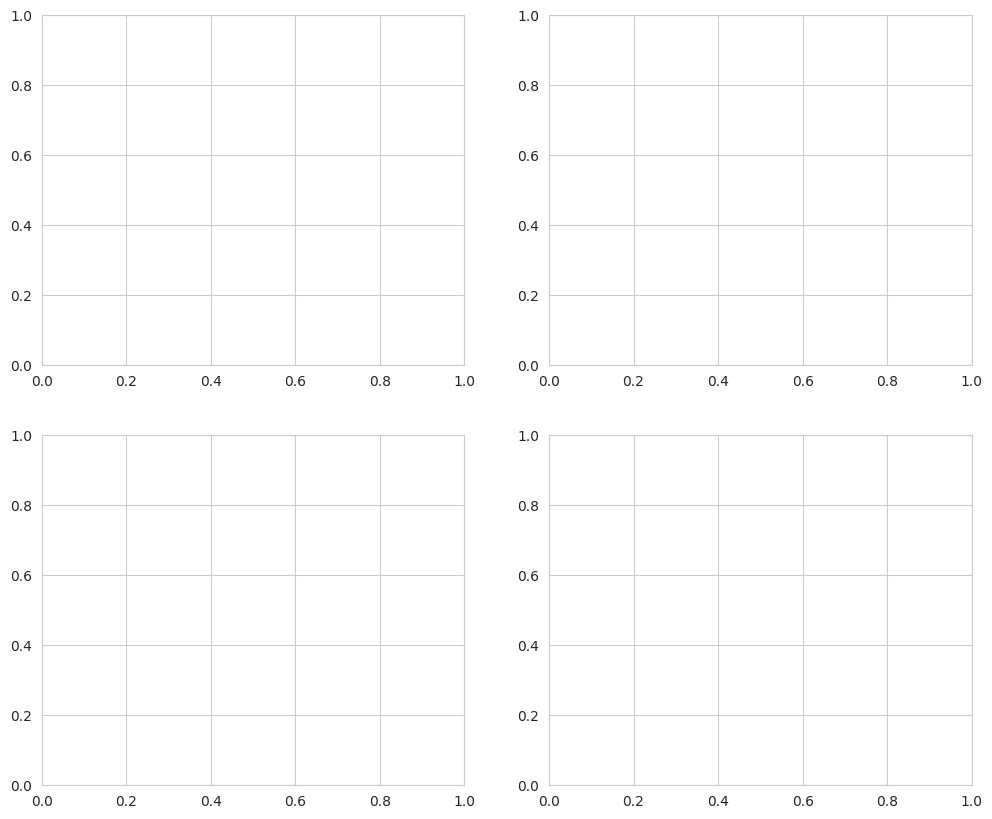

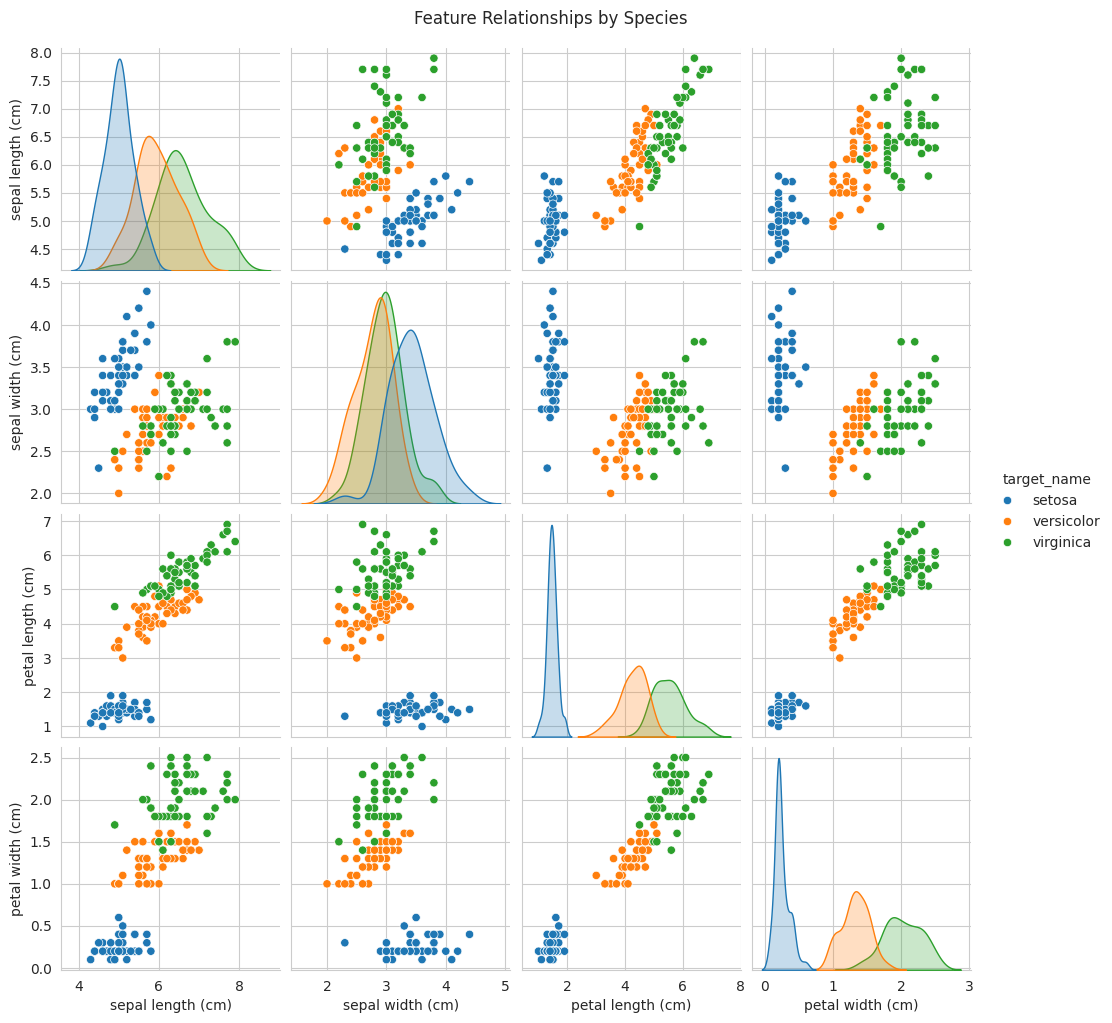

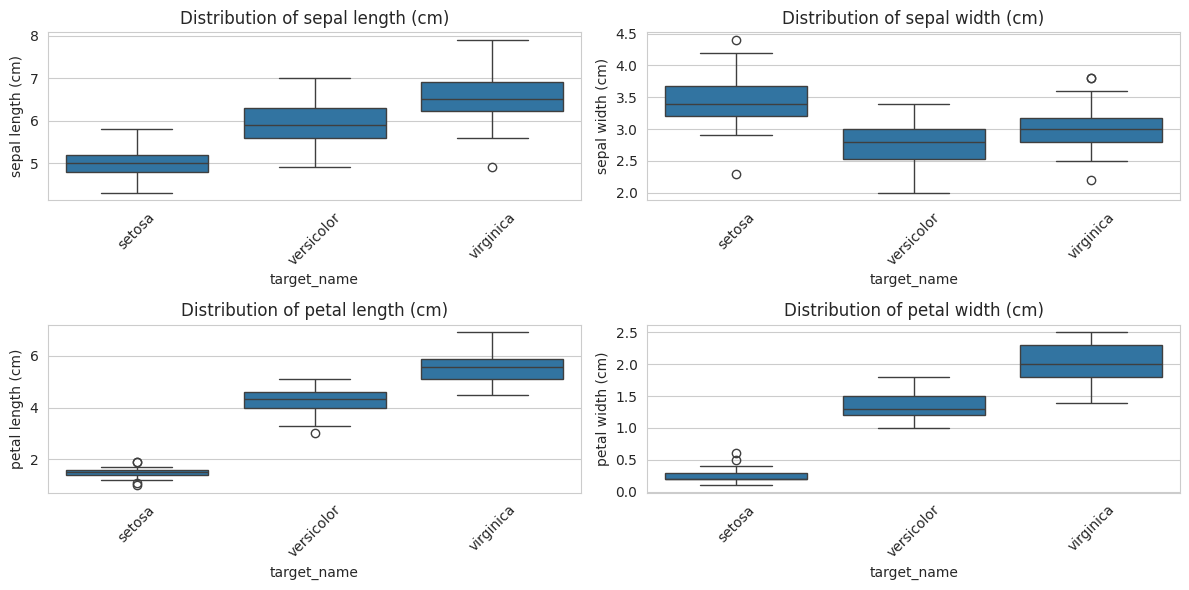

In [3]:
import seaborn as sns

# Set the style
sns.set_style("whitegrid")

# Create a figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. Pairplot of all features colored by species
sns.pairplot(data=iris_df, hue='target_name', vars=iris.feature_names)
plt.suptitle('Feature Relationships by Species', y=1.02)

# 2. Box plots for each feature
plt.figure(figsize=(12, 6))
for i, feature in enumerate(iris.feature_names, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x='target_name', y=feature, data=iris_df)
    plt.title(f'Distribution of {feature}')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

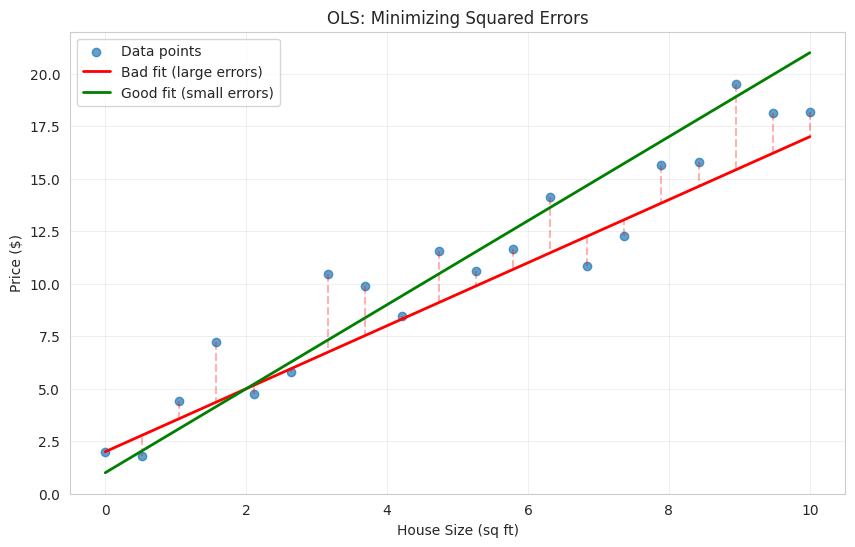

In [4]:
# Visual representation of OLS
import numpy as np
import matplotlib.pyplot as plt

# Generate sample data
np.random.seed(42)
X = np.linspace(0, 10, 20)
y = 2*X + 1 + np.random.randn(20)*2

# Plot with best fit line
plt.figure(figsize=(10, 6))
plt.scatter(X, y, alpha=0.7, label='Data points')

# Show errors for a sample line
bad_line = 1.5*X + 2
for i in range(len(X)):
    plt.plot([X[i], X[i]], [y[i], bad_line[i]], 'r--', alpha=0.3)

plt.plot(X, bad_line, 'r-', label='Bad fit (large errors)', linewidth=2)
plt.plot(X, 2*X + 1, 'g-', label='Good fit (small errors)', linewidth=2)
plt.xlabel('House Size (sq ft)')
plt.ylabel('Price ($)')
plt.title('OLS: Minimizing Squared Errors')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [5]:
# Quick check for multicollinearity
import pandas as pd
from sklearn.datasets import make_regression

# Create sample data
X, y = make_regression(n_samples=100, n_features=3, noise=10, random_state=42)
df = pd.DataFrame(X, columns=['feature_1', 'feature_2', 'feature_3'])

# Check correlations
print("Correlation matrix:")
print(df.corr())

Correlation matrix:
           feature_1  feature_2  feature_3
feature_1   1.000000  -0.120707  -0.048636
feature_2  -0.120707   1.000000  -0.123764
feature_3  -0.048636  -0.123764   1.000000


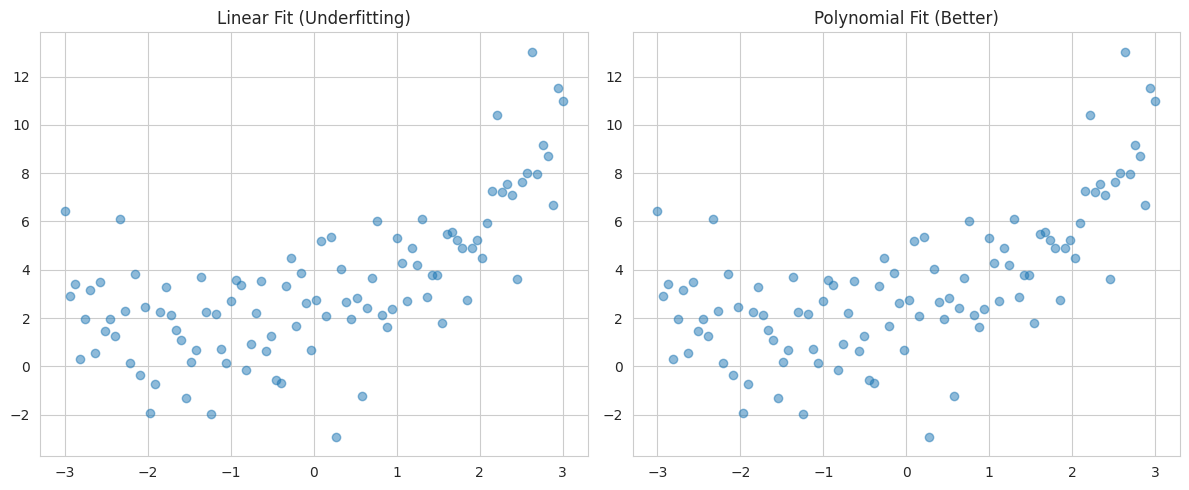

In [6]:
# Generate non-linear data
X = np.linspace(-3, 3, 100)
y = 0.5*X**2 + X + 2 + np.random.randn(100)*2

# Linear fit vs Polynomial fit
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(X, y, alpha=0.5)
plt.title('Linear Fit (Underfitting)')
# Add linear fit line...

plt.subplot(1, 2, 2)
plt.scatter(X, y, alpha=0.5)
plt.title('Polynomial Fit (Better)')
# Add polynomial fit line...

plt.tight_layout()
plt.show()

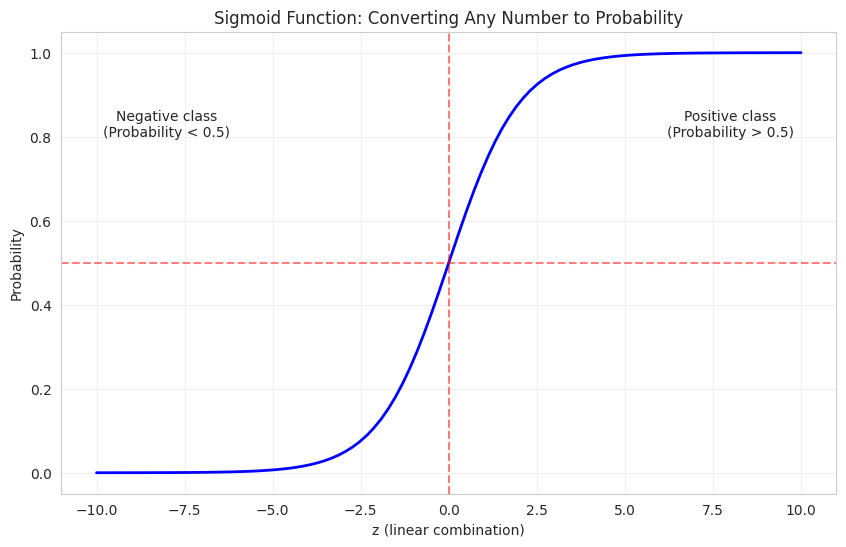

In [7]:
# Visualizing the Sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z = np.linspace(-10, 10, 100)
s = sigmoid(z)

plt.figure(figsize=(10, 6))
plt.plot(z, s, 'b-', linewidth=2)
plt.axhline(y=0.5, color='r', linestyle='--', alpha=0.5)
plt.axvline(x=0, color='r', linestyle='--', alpha=0.5)
plt.xlabel('z (linear combination)')
plt.ylabel('Probability')
plt.title('Sigmoid Function: Converting Any Number to Probability')
plt.grid(True, alpha=0.3)
plt.text(-8, 0.8, 'Negative class\n(Probability < 0.5)', ha='center')
plt.text(8, 0.8, 'Positive class\n(Probability > 0.5)', ha='center')
plt.show()

In [8]:
# Simple logistic regression example
from sklearn.linear_model import LogisticRegression
import numpy as np

# Create simple dataset
X = np.array([[1], [2], [3], [4], [5], [6]])
y = np.array([0, 0, 0, 1, 1, 1])  # 0 = not buy, 1 = buy

# Train model
model = LogisticRegression()
model.fit(X, y)

# Get probabilities for new data
new_points = np.array([[2.5], [3.5], [4.5]])
probs = model.predict_proba(new_points)

for point, prob in zip(new_points, probs):
    print(f"At x={point[0]}: Probability of buying = {prob[1]:.2f}")

At x=2.5: Probability of buying = 0.25
At x=3.5: Probability of buying = 0.50
At x=4.5: Probability of buying = 0.75


In [9]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

# Load the Boston Housing dataset (alternative since original is deprecated)
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['MedHouseVal'] = housing.target

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nDataset info:")
print(df.info())

Dataset shape: (20640, 9)

First 5 rows:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 

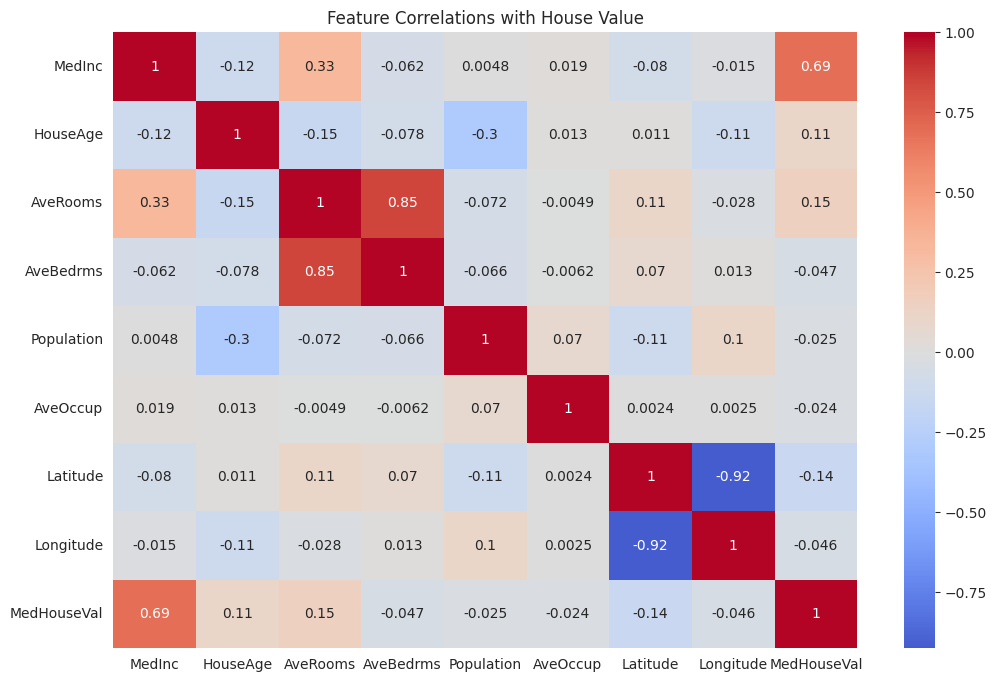


Features most correlated with house value:
MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64


In [10]:
# Check correlations
plt.figure(figsize=(12, 8))
correlation = df.corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0)
plt.title('Feature Correlations with House Value')
plt.show()

# Which features correlate most with house value?
target_corr = correlation['MedHouseVal'].sort_values(ascending=False)
print("\nFeatures most correlated with house value:")
print(target_corr)

In [11]:
# Prepare features and target
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predict and evaluate
y_pred = lr.predict(X_test)

print("Model Performance:")
print(f"R² Score: {r2_score(y_test, y_pred):.3f}")
print(f"RMSE: ${np.sqrt(mean_squared_error(y_test, y_pred))*100000:.0f}")

# Feature importance (coefficients)
coeff_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr.coef_,
    'Abs_Coefficient': np.abs(lr.coef_)
}).sort_values('Abs_Coefficient', ascending=False)

print("\nFeature Importance:")
print(coeff_df)

Model Performance:
R² Score: 0.576
RMSE: $74558

Feature Importance:
      Feature  Coefficient  Abs_Coefficient
3   AveBedrms     0.783145         0.783145
0      MedInc     0.448675         0.448675
7   Longitude    -0.433708         0.433708
6    Latitude    -0.419792         0.419792
2    AveRooms    -0.123323         0.123323
1    HouseAge     0.009724         0.009724
5    AveOccup    -0.003526         0.003526
4  Population    -0.000002         0.000002


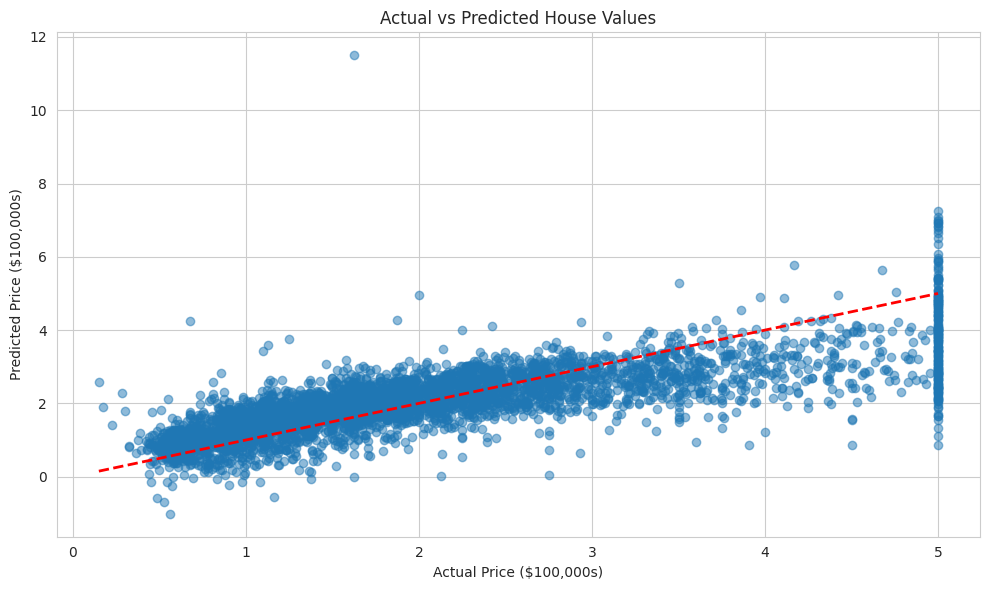

In [12]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Price ($100,000s)')
plt.ylabel('Predicted Price ($100,000s)')
plt.title('Actual vs Predicted House Values')
plt.tight_layout()
plt.show()

In [13]:
# Generate synthetic customer data
np.random.seed(42)
n_customers = 1000

# Create features
data = {
    'tenure': np.random.randint(1, 72, n_customers),  # months
    'monthly_charges': np.random.uniform(20, 120, n_customers),
    'total_charges': np.random.uniform(100, 8000, n_customers),
    'senior_citizen': np.random.choice([0, 1], n_customers, p=[0.8, 0.2]),
    'contract_type': np.random.choice(['monthly', 'yearly', 'two_year'], n_customers),
    'internet_service': np.random.choice(['DSL', 'fiber', 'none'], n_customers)
}

df_customers = pd.DataFrame(data)

# Create target (churn) based on realistic patterns
churn_prob = (
    0.3 * (df_customers['tenure'] < 12) +
    0.2 * (df_customers['monthly_charges'] > 80) +
    0.2 * (df_customers['contract_type'] == 'monthly') +
    0.1 * (df_customers['senior_citizen'] == 1)
)
churn_prob = np.clip(churn_prob, 0, 1)
df_customers['churn'] = np.random.binomial(1, churn_prob)

print("Dataset shape:", df_customers.shape)
print("\nChurn distribution:")
print(df_customers['churn'].value_counts(normalize=True))

Dataset shape: (1000, 7)

Churn distribution:
churn
0    0.79
1    0.21
Name: proportion, dtype: float64


Model Performance:
              precision    recall  f1-score   support

           0       0.81      0.99      0.89       158
           1       0.80      0.10      0.17        42

    accuracy                           0.81       200
   macro avg       0.80      0.54      0.53       200
weighted avg       0.80      0.81      0.74       200



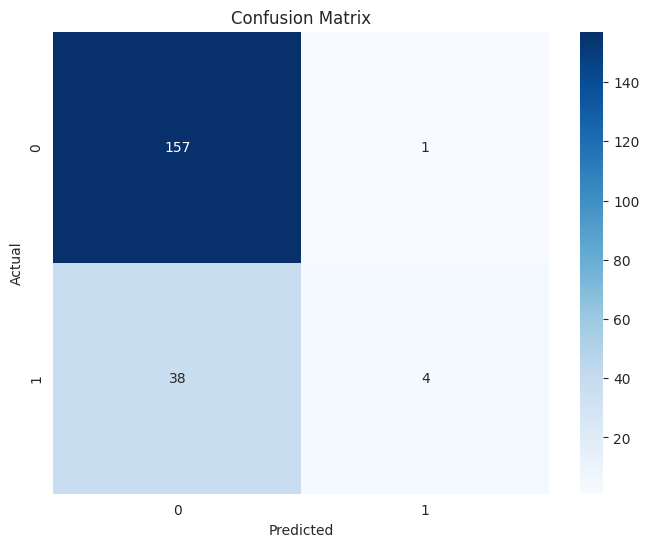

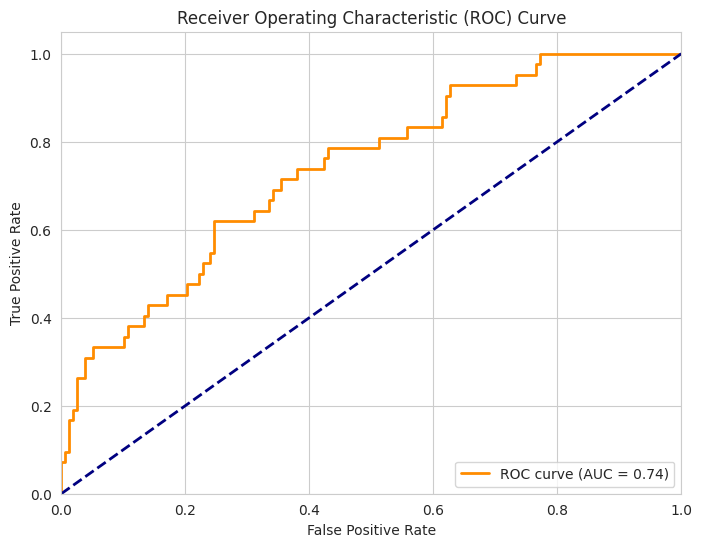

In [14]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# Separate features by type
numeric_features = ['tenure', 'monthly_charges', 'total_charges', 'senior_citizen']
categorical_features = ['contract_type', 'internet_service']

# Create preprocessing pipelines
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(drop='first', sparse_output=False))
])

# Combine preprocessors
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Create full pipeline with logistic regression
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42))
])

# Split data
X = df_customers.drop('churn', axis=1)
y = df_customers['churn']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Train model
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Evaluate
print("Model Performance:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

In [15]:
# Get feature names after preprocessing
feature_names = (numeric_features +
                 [f"{feat}_{val}" for feat, vals in
                  zip(categorical_features,
                      model.named_steps['preprocessor']
                      .named_transformers_['cat']
                      .named_steps['onehot'].categories_)
                  for val in vals[1:]])

# Get coefficients
coefficients = model.named_steps['classifier'].coef_[0]
odds_ratios = np.exp(coefficients)

# Create dataframe
coeff_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients,
    'Odds_Ratio': odds_ratios,
    'Impact': ['Increases churn' if coef > 0 else 'Decreases churn' for coef in coefficients]
}).sort_values('Coefficient', ascending=False)

print("\nFeature Impact on Churn:")
print(coeff_df)


Feature Impact on Churn:
                  Feature  Coefficient  Odds_Ratio           Impact
1         monthly_charges     0.514271    1.672419  Increases churn
3          senior_citizen     0.089938    1.094106  Increases churn
2           total_charges     0.049882    1.051147  Increases churn
6  internet_service_fiber    -0.139537    0.869761  Decreases churn
7   internet_service_none    -0.193440    0.824119  Decreases churn
0                  tenure    -0.502892    0.604779  Decreases churn
4  contract_type_two_year    -0.733017    0.480457  Decreases churn
5    contract_type_yearly    -0.810470    0.444649  Decreases churn


In [16]:
import numpy as np
import pandas as pd
# Generate realistic student data
np.random.seed(42)
n_students = 500

data = {
    'hours_studied': np.random.uniform(0, 20, n_students),
    'previous_scores': np.random.uniform(40, 100, n_students),
    'sleep_hours': np.random.uniform(4, 10, n_students),
    'practice_tests': np.random.randint(0, 5, n_students),
    'extracurricular': np.random.choice([0, 1], n_students, p=[0.6, 0.4])
}

df_students = pd.DataFrame(data)

# Create target (final score) with realistic relationships
df_students['final_score'] = (
    30 +
    2.5 * df_students['hours_studied'] +
    0.3 * df_students['previous_scores'] +
    1.5 * df_students['sleep_hours'] +
    3 * df_students['practice_tests'] +
    2 * df_students['extracurricular'] +
    np.random.normal(0, 5, n_students)  # add noise
)

# Clip to reasonable range
df_students['final_score'] = df_students['final_score'].clip(0, 100)

print(df_students.head())

   hours_studied  previous_scores  sleep_hours  practice_tests  \
0       7.490802        81.889703     5.110798               1   
1      19.014286        72.165782     7.251406               3   
2      14.639879        58.571657     9.237675               4   
3      11.973170        88.827701     8.393349               4   
4       3.120373        81.083870     8.839367               1   

   extracurricular  final_score  
0                0    90.328315  
1                0   100.000000  
2                0   100.000000  
3                1   100.000000  
4                1    80.920945  


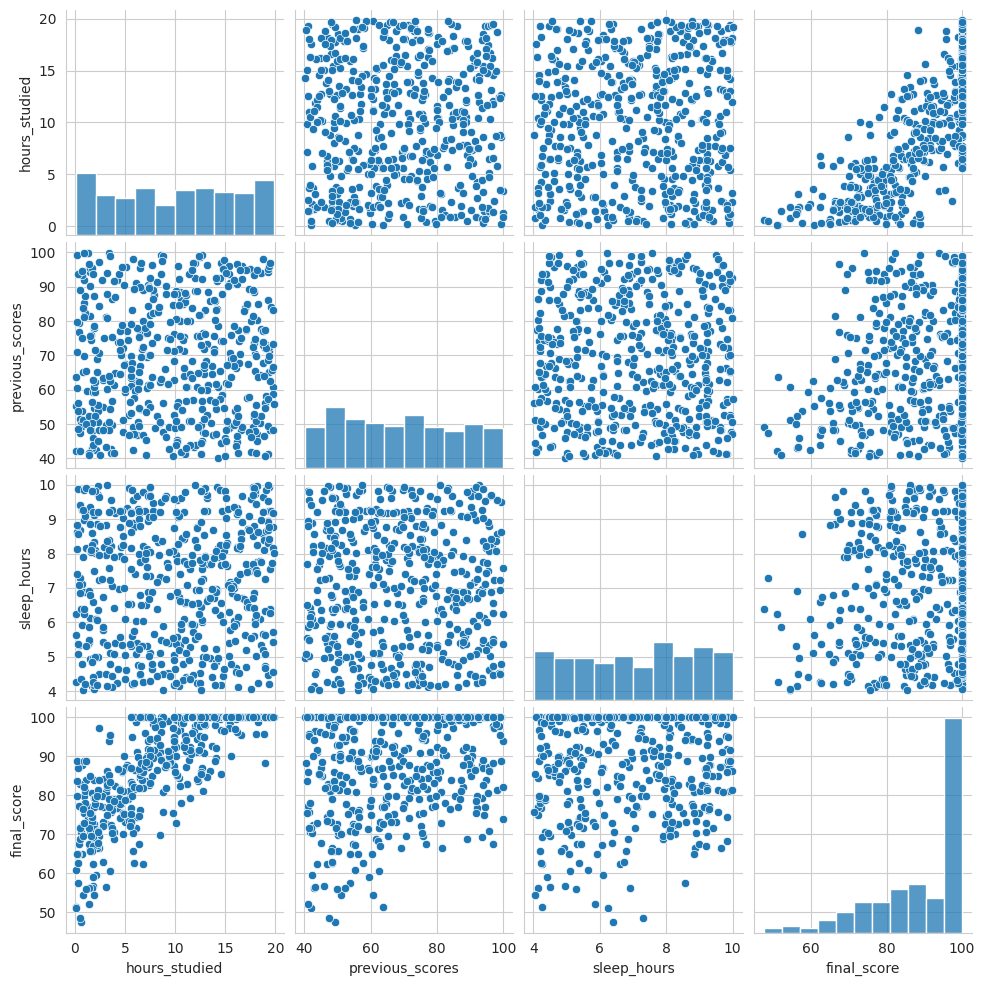

Simple R²: 0.665
Simple RMSE: 7.35
Multiple R²: 0.816
Multiple RMSE: 5.45


In [17]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Task 1 Solution (partial)
sns.pairplot(df_students, vars=['hours_studied', 'previous_scores', 'sleep_hours', 'final_score'])
plt.show()

# Task 2 Solution
X_simple = df_students[['hours_studied']]
y = df_students['final_score']
X_train, X_test, y_train, y_test = train_test_split(X_simple, y, test_size=0.2, random_state=42)

simple_model = LinearRegression()
simple_model.fit(X_train, y_train)
y_pred = simple_model.predict(X_test)

print(f"Simple R²: {r2_score(y_test, y_pred):.3f}")
print(f"Simple RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")

# Task 3 Solution
X_multi = df_students.drop('final_score', axis=1)
X_train, X_test, y_train, y_test = train_test_split(X_multi, y, test_size=0.2, random_state=42)

multi_model = LinearRegression()
multi_model.fit(X_train, y_train)
y_pred_multi = multi_model.predict(X_test)

print(f"Multiple R²: {r2_score(y_test, y_pred_multi):.3f}")
print(f"Multiple RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_multi)):.2f}")

In [18]:
# You're given this dataset:
import pandas as pd
data = {
    'ad_spend': [100, 200, 300, 400, 500, 600, 700, 800],
    'sales': [12, 25, 35, 48, 52, 58, 61, 63]
}
df = pd.DataFrame(data)

# Tasks:
# 1. Build a linear regression model
# 2. Build a polynomial regression model (degree 2)
# 3. Which performs better? Why?
# 4. Predict sales for ad_spend = 550

--- Linear Regression Model ---
R² Score: 0.926
RMSE: 4.699

--- Polynomial Regression Model (Degree 2) ---
R² Score: 0.996
RMSE: 1.038

--- Model Comparison ---
The Polynomial Regression model (degree 2) performs better.
This is likely because the relationship between ad_spend and sales appears non-linear, with diminishing returns at higher ad spends. A polynomial model can capture this curvature better than a straight line.


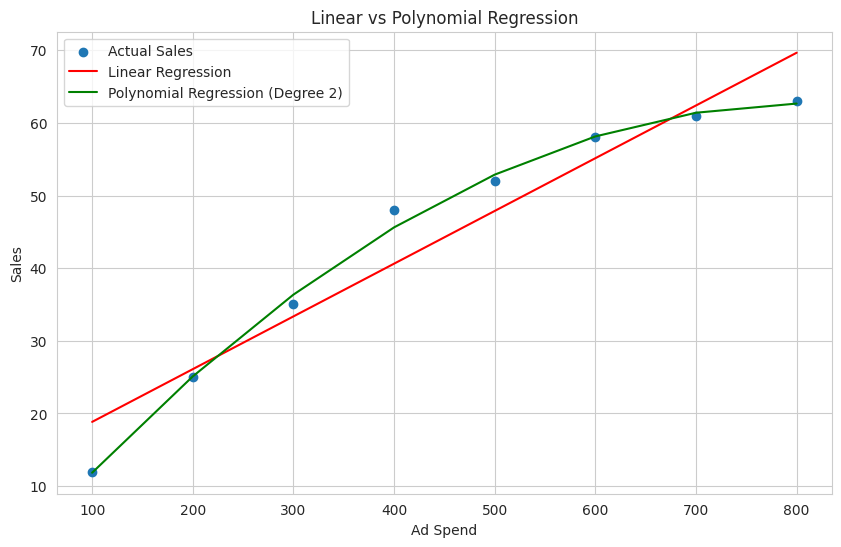


Predicted sales for ad_spend = 550 (Linear Model): 51.51
Predicted sales for ad_spend = 550 (Polynomial Model): 55.76


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


In [19]:
# 1. Build a linear regression model
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

X = df[['ad_spend']]
y = df['sales']

# Linear Regression
linear_model = LinearRegression()
linear_model.fit(X, y)

y_pred_linear = linear_model.predict(X)
r2_linear = r2_score(y, y_pred_linear)
rmse_linear = np.sqrt(mean_squared_error(y, y_pred_linear))

print("--- Linear Regression Model ---")
print(f"R² Score: {r2_linear:.3f}")
print(f"RMSE: {rmse_linear:.3f}")

# 2. Build a polynomial regression model (degree 2)
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

poly_model = LinearRegression()
poly_model.fit(X_poly, y)

y_pred_poly = poly_model.predict(X_poly)
r2_poly = r2_score(y, y_pred_poly)
rmse_poly = np.sqrt(mean_squared_error(y, y_pred_poly))

print("\n--- Polynomial Regression Model (Degree 2) ---")
print(f"R² Score: {r2_poly:.3f}")
print(f"RMSE: {rmse_poly:.3f}")

# 3. Which performs better? Why?
print("\n--- Model Comparison ---")
if r2_poly > r2_linear:
    print("The Polynomial Regression model (degree 2) performs better.")
    print("This is likely because the relationship between ad_spend and sales appears non-linear, with diminishing returns at higher ad spends. A polynomial model can capture this curvature better than a straight line.")
else:
    print("The Linear Regression model performs better.")

plt.figure(figsize=(10, 6))
plt.scatter(X, y, label='Actual Sales')
plt.plot(X, y_pred_linear, color='red', label='Linear Regression')
plt.plot(X, y_pred_poly, color='green', label='Polynomial Regression (Degree 2)')
plt.title('Linear vs Polynomial Regression')
plt.xlabel('Ad Spend')
plt.ylabel('Sales')
plt.legend()
plt.grid(True)
plt.show()

# 4. Predict sales for ad_spend = 550
ad_spend_new = np.array([[550]])

predicted_sales_linear = linear_model.predict(ad_spend_new)
print(f"\nPredicted sales for ad_spend = 550 (Linear Model): {predicted_sales_linear[0]:.2f}")

ad_spend_new_poly = poly.transform(ad_spend_new)
predicted_sales_poly = poly_model.predict(ad_spend_new_poly)
print(f"Predicted sales for ad_spend = 550 (Polynomial Model): {predicted_sales_poly[0]:.2f}")

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import StandardScaler

# Your original data
data = {
    'ad_spend': [100, 200, 300, 400, 500, 600, 700, 800],
    'sales': [12, 25, 35, 48, 52, 58, 61, 63]
}
df = pd.DataFrame(data)

# Create binary target: High Sales vs Low Sales
# Let's define "high sales" as above median
median_sales = df['sales'].median()
df['high_sales'] = (df['sales'] > median_sales).astype(int)

print("Original Data with Classification Target:")
print(df)
print(f"\nMedian Sales: {median_sales}")
print("Class distribution:")
print(df['high_sales'].value_counts())

Original Data with Classification Target:
   ad_spend  sales  high_sales
0       100     12           0
1       200     25           0
2       300     35           0
3       400     48           0
4       500     52           1
5       600     58           1
6       700     61           1
7       800     63           1

Median Sales: 50.0
Class distribution:
high_sales
0    4
1    4
Name: count, dtype: int64


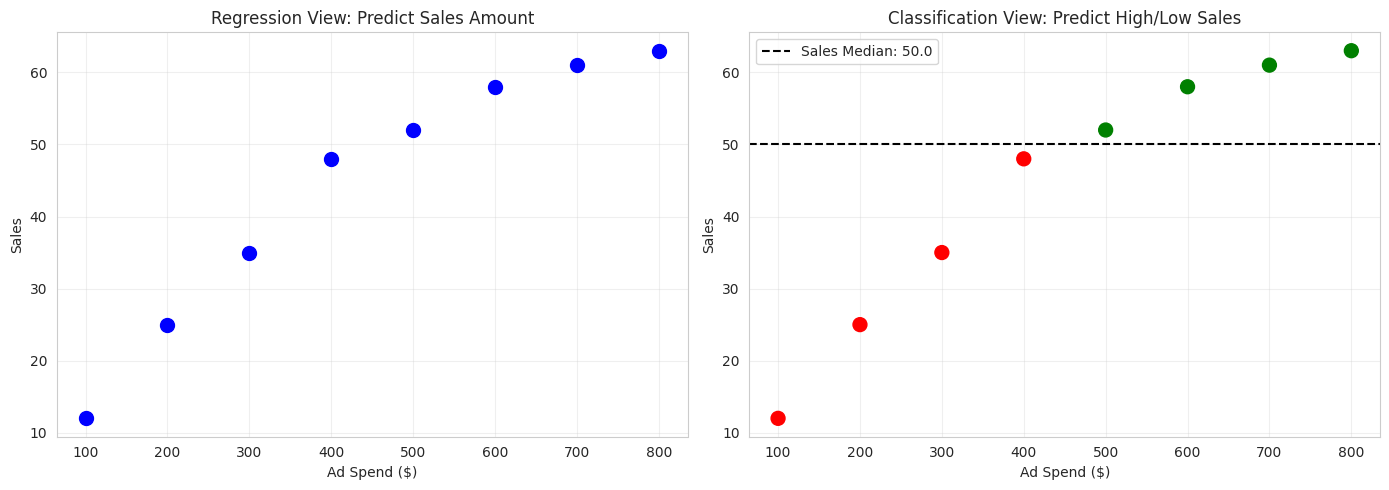

In [21]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Original regression view
ax1.scatter(df['ad_spend'], df['sales'], c='blue', s=100)
ax1.set_xlabel('Ad Spend ($)')
ax1.set_ylabel('Sales')
ax1.set_title('Regression View: Predict Sales Amount')
ax1.grid(True, alpha=0.3)

# Plot 2: New classification view
colors = ['red' if x == 0 else 'green' for x in df['high_sales']]
ax2.scatter(df['ad_spend'], df['sales'], c=colors, s=100)
ax2.axhline(y=median_sales, color='black', linestyle='--', label=f'Sales Median: {median_sales}')
ax2.set_xlabel('Ad Spend ($)')
ax2.set_ylabel('Sales')
ax2.set_title('Classification View: Predict High/Low Sales')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [22]:
# Prepare data
X = df[['ad_spend']].values
y = df['high_sales'].values

# Split data (though with small dataset, we'll use all for demonstration)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Scale features (important for logistic regression!)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train logistic regression
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_scaled, y_train)

# Get predictions
y_pred = log_reg.predict(X_test_scaled)
y_pred_proba = log_reg.predict_proba(X_test_scaled)

print("Logistic Regression Results:")
print(f"Training Accuracy: {log_reg.score(X_train_scaled, y_train):.3f}")
print(f"Test Accuracy: {log_reg.score(X_test_scaled, y_test):.3f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Logistic Regression Results:
Training Accuracy: 1.000
Test Accuracy: 0.667

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.50      0.67         2
           1       0.50      1.00      0.67         1

    accuracy                           0.67         3
   macro avg       0.75      0.75      0.67         3
weighted avg       0.83      0.67      0.67         3


Confusion Matrix:
[[1 1]
 [0 1]]


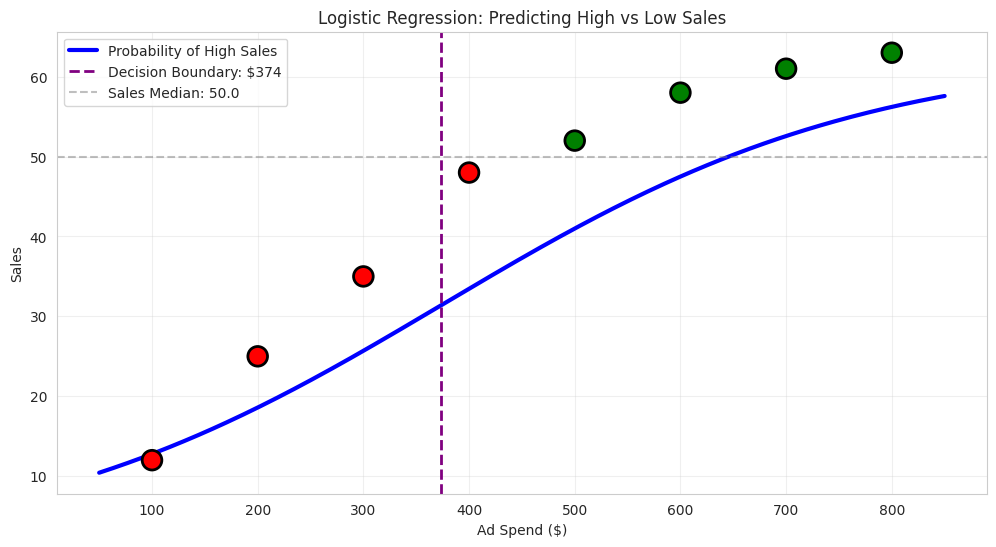


Model Interpretation:
The model predicts HIGH sales when ad spend > $374
Coefficient: 1.063
Intercept: 0.523
Odds Ratio: 2.894
Interpretation: For a 1-standard-deviation increase in ad spend,
the odds of high sales increase by 189.4%


In [23]:
# Create smooth line for visualization
X_smooth = np.linspace(df['ad_spend'].min() - 50, df['ad_spend'].max() + 50, 300).reshape(-1, 1)
X_smooth_scaled = scaler.transform(X_smooth)
y_smooth_proba = log_reg.predict_proba(X_smooth_scaled)[:, 1]

plt.figure(figsize=(12, 6))

# Plot data points
colors = ['red' if x == 0 else 'green' for x in df['high_sales']]
plt.scatter(df['ad_spend'], df['sales'], c=colors, s=200, edgecolors='black', linewidth=2, zorder=5)

# Plot probability curve
plt.plot(X_smooth, y_smooth_proba * df['sales'].max(), 'b-', linewidth=3, label='Probability of High Sales')

# Plot decision boundary (where probability = 0.5)
decision_boundary_idx = np.argmin(np.abs(y_smooth_proba - 0.5))
decision_boundary = X_smooth[decision_boundary_idx][0]
plt.axvline(x=decision_boundary, color='purple', linestyle='--', linewidth=2,
            label=f'Decision Boundary: ${decision_boundary:.0f}')

plt.axhline(y=median_sales, color='gray', linestyle='--', alpha=0.5, label=f'Sales Median: {median_sales}')

plt.xlabel('Ad Spend ($)')
plt.ylabel('Sales')
plt.title('Logistic Regression: Predicting High vs Low Sales')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"\nModel Interpretation:")
print(f"The model predicts HIGH sales when ad spend > ${decision_boundary:.0f}")
print(f"Coefficient: {log_reg.coef_[0][0]:.3f}")
print(f"Intercept: {log_reg.intercept_[0]:.3f}")

# Calculate odds ratio
odds_ratio = np.exp(log_reg.coef_[0][0])
print(f"Odds Ratio: {odds_ratio:.3f}")
print(f"Interpretation: For a 1-standard-deviation increase in ad spend,")
print(f"the odds of high sales increase by {(odds_ratio-1)*100:.1f}%")

In [24]:
print("="*50)
print("MODEL COMPARISON")
print("="*50)

print("\n📈 POLYNOMIAL REGRESSION (Degree 2)")
print(f"   R² Score: 0.996")
print(f"   RMSE: 1.038")
print(f"   What it tells us: Sales amount = f(ad_spend)")
print(f"   Business use: 'How many units will we sell?'")

print("\n📊 LOGISTIC REGRESSION")
print(f"   Accuracy: {log_reg.score(X_test_scaled, y_test):.3f}")
print(f"   Decision Boundary: ${decision_boundary:.0f}")
print(f"   What it tells us: P(High Sales | ad_spend)")
print(f"   Business use: 'Will this campaign achieve high sales?'")

print("\n🎯 KEY DIFFERENCE:")
print("   - Polynomial Regression: Predicts EXACT sales amount")
print("   - Logistic Regression: Predicts PROBABILITY of being in high-sales category")

MODEL COMPARISON

📈 POLYNOMIAL REGRESSION (Degree 2)
   R² Score: 0.996
   RMSE: 1.038
   What it tells us: Sales amount = f(ad_spend)
   Business use: 'How many units will we sell?'

📊 LOGISTIC REGRESSION
   Accuracy: 0.667
   Decision Boundary: $374
   What it tells us: P(High Sales | ad_spend)
   Business use: 'Will this campaign achieve high sales?'

🎯 KEY DIFFERENCE:
   - Polynomial Regression: Predicts EXACT sales amount
   - Logistic Regression: Predicts PROBABILITY of being in high-sales category


## **Visual Comparison of Regularization Effects**

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.487e+01, tolerance: 4.763e-02
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.054e+01, tolerance: 4.763e-02
  model = cd_fast.enet_coordinate_descent(


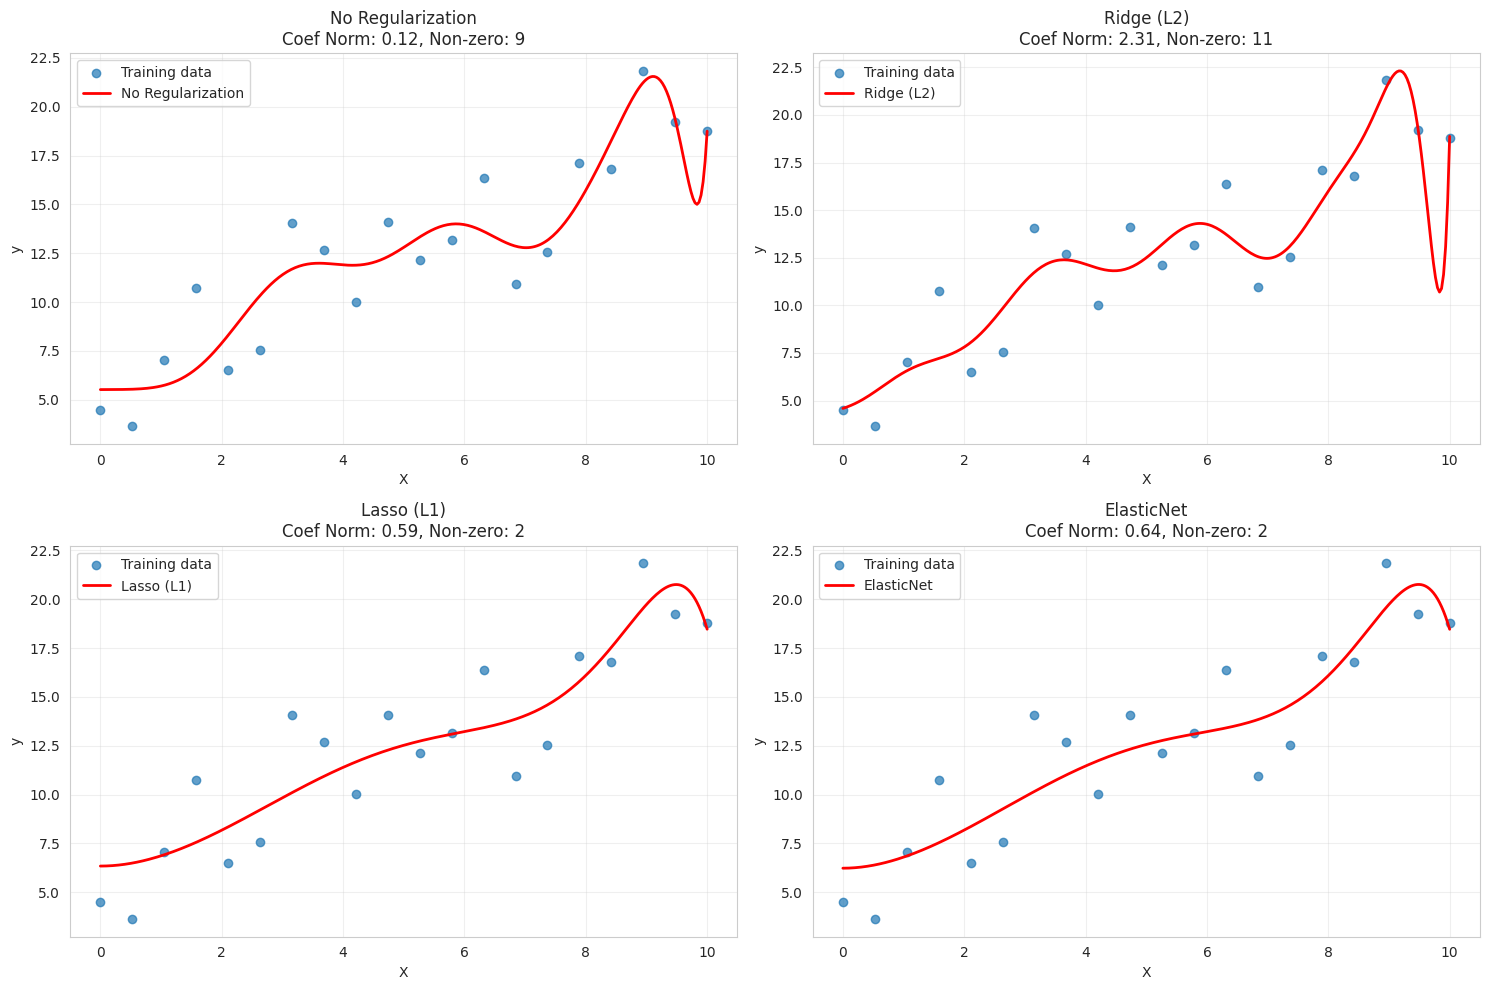

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

# Generate synthetic data to demonstrate regularization
np.random.seed(42)
X = np.linspace(0, 10, 20).reshape(-1, 1)
y = 2*X.ravel() + 3 + np.random.randn(20)*3

# Create complex polynomial features
poly = PolynomialFeatures(degree=15)
X_poly = poly.fit_transform(X)

# Train different models
models = {
    'No Regularization': LinearRegression(),
    'Ridge (L2)': Ridge(alpha=1.0),
    'Lasso (L1)': Lasso(alpha=1.0),
    'ElasticNet': ElasticNet(alpha=1.0, l1_ratio=0.5)
}

plt.figure(figsize=(15, 10))
X_test = np.linspace(0, 10, 300).reshape(-1, 1)
X_test_poly = poly.transform(X_test)

for i, (name, model) in enumerate(models.items(), 1):
    plt.subplot(2, 2, i)

    # Plot original data
    plt.scatter(X, y, alpha=0.7, label='Training data')

    # Fit and predict
    model.fit(X_poly, y)
    y_pred = model.predict(X_test_poly)

    # Plot model predictions
    plt.plot(X_test, y_pred, 'r-', linewidth=2, label=name)

    # Show coefficient magnitudes
    if hasattr(model, 'coef_'):
        coef_norm = np.linalg.norm(model.coef_)
        non_zero = np.sum(np.abs(model.coef_) > 0.01)
        plt.title(f'{name}\nCoef Norm: {coef_norm:.2f}, Non-zero: {non_zero}')

    plt.xlabel('X')
    plt.ylabel('y')
    plt.legend()
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# REGULARIZING YOUR POLYNOMIAL REGRESSION **MODEL** bold text

Original Polynomial Model with **Diagnostics**

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import r2_score, mean_squared_error

# Your data
data = {
    'ad_spend': [100, 200, 300, 400, 500, 600, 700, 800],
    'sales': [12, 25, 35, 48, 52, 58, 61, 63]
}
df = pd.DataFrame(data)

X = df[['ad_spend']].values
y = df['sales'].values

# Original polynomial model (without regularization)
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

original_model = LinearRegression()
original_model.fit(X_poly, y)
y_pred_original = original_model.predict(X_poly)

# Calculate metrics
r2_original = r2_score(y, y_pred_original)
rmse_original = np.sqrt(mean_squared_error(y, y_pred_original))

print("="*60)
print("ORIGINAL POLYNOMIAL MODEL (Degree 2)")
print("="*60)
print(f"R² Score: {r2_original:.4f}")
print(f"RMSE: {rmse_original:.4f}")
print(f"Coefficients: {original_model.coef_}")
print(f"Intercept: {original_model.intercept_:.4f}")

# Cross-validation to detect overfitting
kfold = KFold(n_splits=3, shuffle=True, random_state=42)
cv_scores = cross_val_score(original_model, X_poly, y, cv=kfold, scoring='r2')
print(f"\nCross-validation R² scores: {cv_scores}")
print(f"Mean CV R²: {np.mean(cv_scores):.4f} (+/- {np.std(cv_scores)*2:.4f})")

# If CV scores vary greatly, model is overfitting!
cv_variance = np.std(cv_scores)
if cv_variance > 0.1:
    print("⚠️ High variance in CV scores - model may be overfitting!")

ORIGINAL POLYNOMIAL MODEL (Degree 2)
R² Score: 0.9964
RMSE: 1.0380
Coefficients: [ 0.00000000e+00  1.62619048e-01 -1.00000000e-04]
Intercept: -3.4286

Cross-validation R² scores: [0.99653195 0.95265845 0.87171793]
Mean CV R²: 0.9403 (+/- 0.1034)


Implement Ridge **Regularization**

In [27]:
# Create pipeline with Ridge regularization
ridge_model = Pipeline([
    ('poly', PolynomialFeatures(degree=2)),
    ('scaler', StandardScaler()),  # Important for regularization!
    ('ridge', Ridge(alpha=1.0))     # alpha = regularization strength
])

# Train model
ridge_model.fit(X, y)
y_pred_ridge = ridge_model.predict(X)

# Calculate metrics
r2_ridge = r2_score(y, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y, y_pred_ridge))

print("="*60)
print("RIDGE-REGULARIZED POLYNOMIAL MODEL")
print("="*60)
print(f"R² Score: {r2_ridge:.4f}")
print(f"RMSE: {rmse_ridge:.4f}")

# Get coefficients
ridge_coef = ridge_model.named_steps['ridge'].coef_
print(f"Ridge Coefficients: {ridge_coef}")

# Cross-validation
X_poly_scaled = ridge_model.named_steps['scaler'].fit_transform(X_poly)
ridge_cv_scores = cross_val_score(ridge_model.named_steps['ridge'],
                                  X_poly_scaled, y, cv=kfold, scoring='r2')
print(f"\nRidge CV R² scores: {ridge_cv_scores}")
print(f"Mean Ridge CV R²: {np.mean(ridge_cv_scores):.4f} (+/- {np.std(ridge_cv_scores)*2:.4f})")

RIDGE-REGULARIZED POLYNOMIAL MODEL
R² Score: 0.8976
RMSE: 5.5340
Ridge Coefficients: [ 0.         12.25945798  2.91667859]

Ridge CV R² scores: [ 0.33666916  0.69080045 -0.0471238 ]
Mean Ridge CV R²: 0.3268 (+/- 0.6027)


Find the Optimal Regularization Strength (Alpha)**bold text**

In [28]:
from sklearn.model_selection import GridSearchCV

# Create parameter grid
param_grid = {
    'ridge__alpha': [0.001, 0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0]
}

# Create pipeline
ridge_tuned = Pipeline([
    ('poly', PolynomialFeatures(degree=2)),
    ('scaler', StandardScaler()),
    ('ridge', Ridge())
])

# Grid search
grid_search = GridSearchCV(ridge_tuned, param_grid, cv=3, scoring='r2', n_jobs=-1)
grid_search.fit(X, y)

print("="*60)
print("HYPERPARAMETER TUNING RESULTS")
print("="*60)
print(f"Best alpha: {grid_search.best_params_['ridge__alpha']}")
print(f"Best CV R²: {grid_search.best_score_:.4f}")

# Train best model
best_ridge = grid_search.best_estimator_
y_pred_best = best_ridge.predict(X)
r2_best = r2_score(y, y_pred_best)
rmse_best = np.sqrt(mean_squared_error(y, y_pred_best))

print(f"\nBest Model Performance:")
print(f"R² Score: {r2_best:.4f}")
print(f"RMSE: {rmse_best:.4f}")

HYPERPARAMETER TUNING RESULTS
Best alpha: 0.001
Best CV R²: 0.3027

Best Model Performance:
R² Score: 0.9964
RMSE: 1.0385


Visualize Regularization **Effect**

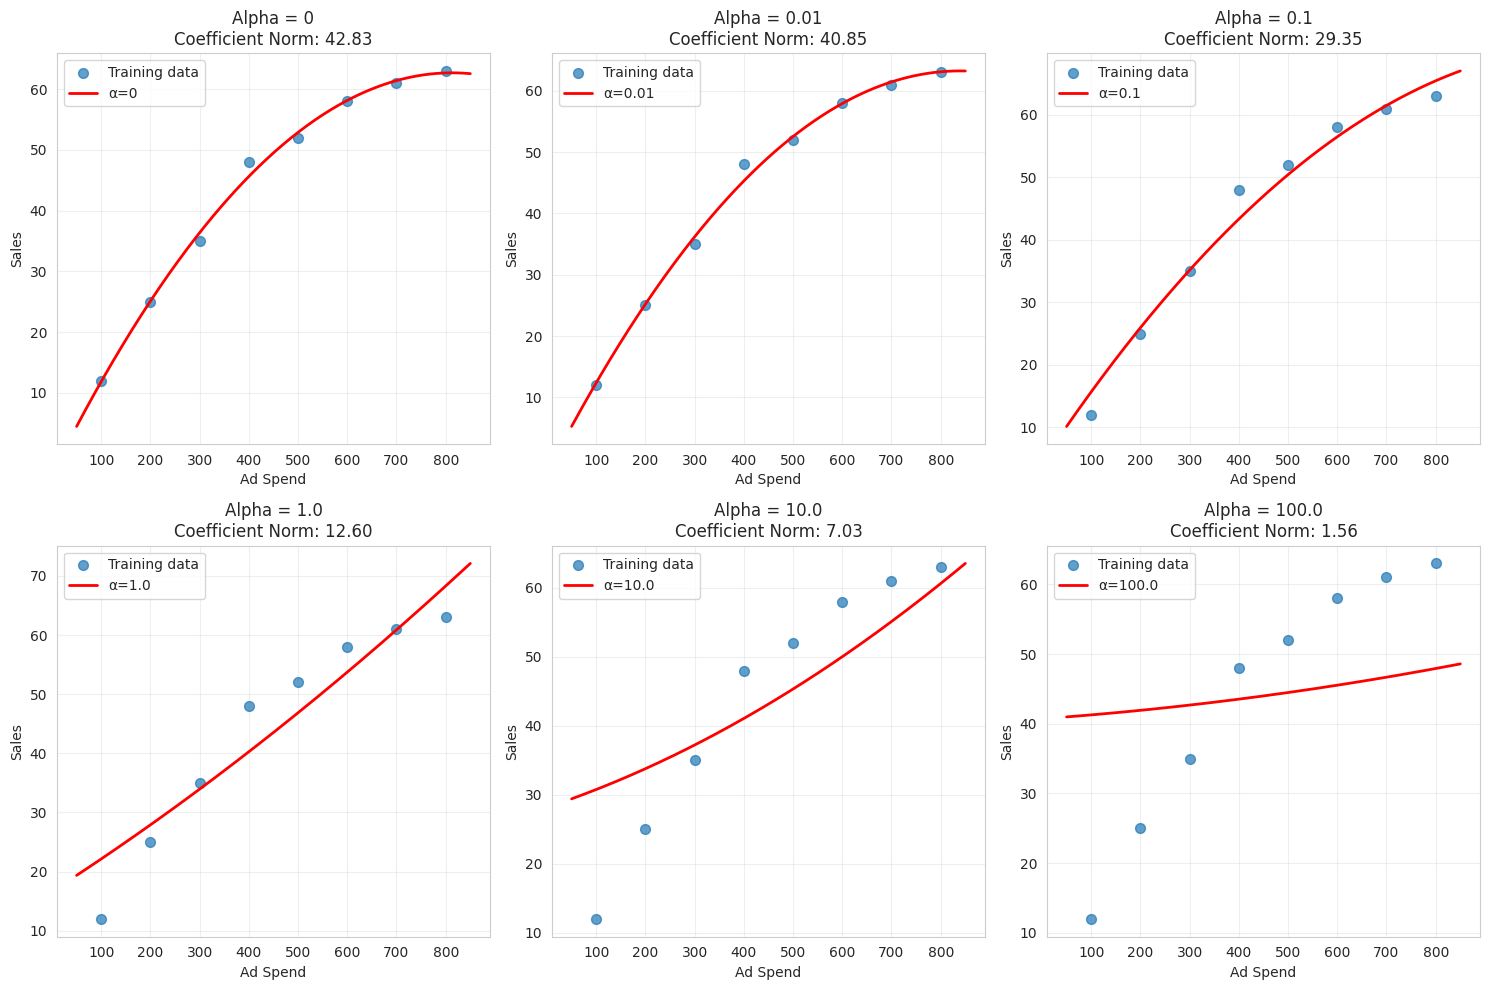

In [29]:
# Test different alphas
alphas = [0, 0.01, 0.1, 1.0, 10.0, 100.0]
X_test = np.linspace(50, 850, 300).reshape(-1, 1)

plt.figure(figsize=(15, 10))

for i, alpha in enumerate(alphas, 1):
    plt.subplot(2, 3, i)

    # Create model
    model = Pipeline([
        ('poly', PolynomialFeatures(degree=2)),
        ('scaler', StandardScaler()),
        ('ridge', Ridge(alpha=alpha))
    ])

    # Fit and predict
    model.fit(X, y)
    y_pred = model.predict(X_test)

    # Plot
    plt.scatter(X, y, alpha=0.7, s=50, label='Training data')
    plt.plot(X_test, y_pred, 'r-', linewidth=2, label=f'α={alpha}')

    # Get coefficients
    coef = model.named_steps['ridge'].coef_
    coef_norm = np.linalg.norm(coef)

    plt.title(f'Alpha = {alpha}\nCoefficient Norm: {coef_norm:.2f}')
    plt.xlabel('Ad Spend')
    plt.ylabel('Sales')
    plt.legend()
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

DECISION TREES

💻 Implementation with Titanic Dataset

In [30]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder

# Load Titanic dataset
titanic = sns.load_dataset('titanic')
print("Titanic Dataset Shape:", titanic.shape)
print("\nFirst 5 rows:")
print(titanic.head())

# Let's understand what we're predicting
print("\nSurvival Distribution:")
print(titanic['survived'].value_counts(normalize=True))

Titanic Dataset Shape: (891, 15)

First 5 rows:
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  

Survival Distribution:
survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64


Data Preprocessing for Titanic

In [31]:
# Select features for our model
features = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']
X = titanic[features].copy()
y = titanic['survived']

# Handle missing values
print("Missing values before handling:")
print(X.isnull().sum())

# Fill missing ages with median
X['age'].fillna(X['age'].median(), inplace=True)

# Fill missing embarked with mode
X['embarked'].fillna(X['embarked'].mode()[0], inplace=True)

# Convert categorical variables to numbers
le_sex = LabelEncoder()
X['sex'] = le_sex.fit_transform(X['sex'])  # male: 1, female: 0

le_embarked = LabelEncoder()
X['embarked'] = le_embarked.fit_transform(X['embarked'])  # C:0, Q:1, S:2

print("\nMissing values after handling:")
print(X.isnull().sum())

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")

Missing values before handling:
pclass        0
sex           0
age         177
sibsp         0
parch         0
fare          0
embarked      2
dtype: int64

Missing values after handling:
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
dtype: int64

Training set size: 712
Test set size: 179


/tmp/ipykernel_11255/2187828676.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X['age'].fillna(X['age'].median(), inplace=True)
/tmp/ipykernel_11255/2187828676.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', 

Building Our First Decision Tree

In [32]:
# Create and train decision tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# Make predictions
y_pred_dt = dt_model.predict(X_test)
y_pred_proba_dt = dt_model.predict_proba(X_test)[:, 1]

# Evaluate
print("="*60)
print("DECISION TREE CLASSIFIER")
print("="*60)
print(f"Training Accuracy: {dt_model.score(X_train, y_train):.3f}")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_dt):.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt, target_names=['Died', 'Survived']))

# Cross-validation
cv_scores = cross_val_score(dt_model, X_train, y_train, cv=5)
print(f"\nCross-validation scores: {cv_scores}")
print(f"Mean CV Accuracy: {cv_scores.mean():.3f} (+/- {cv_scores.std()*2:.3f})")

DECISION TREE CLASSIFIER
Training Accuracy: 0.982
Test Accuracy: 0.832

Classification Report:
              precision    recall  f1-score   support

        Died       0.85      0.88      0.87       110
    Survived       0.80      0.75      0.78        69

    accuracy                           0.83       179
   macro avg       0.83      0.82      0.82       179
weighted avg       0.83      0.83      0.83       179


Cross-validation scores: [0.77622378 0.72727273 0.8028169  0.8028169  0.81690141]
Mean CV Accuracy: 0.785 (+/- 0.064)


Visualizing the Decision Tree

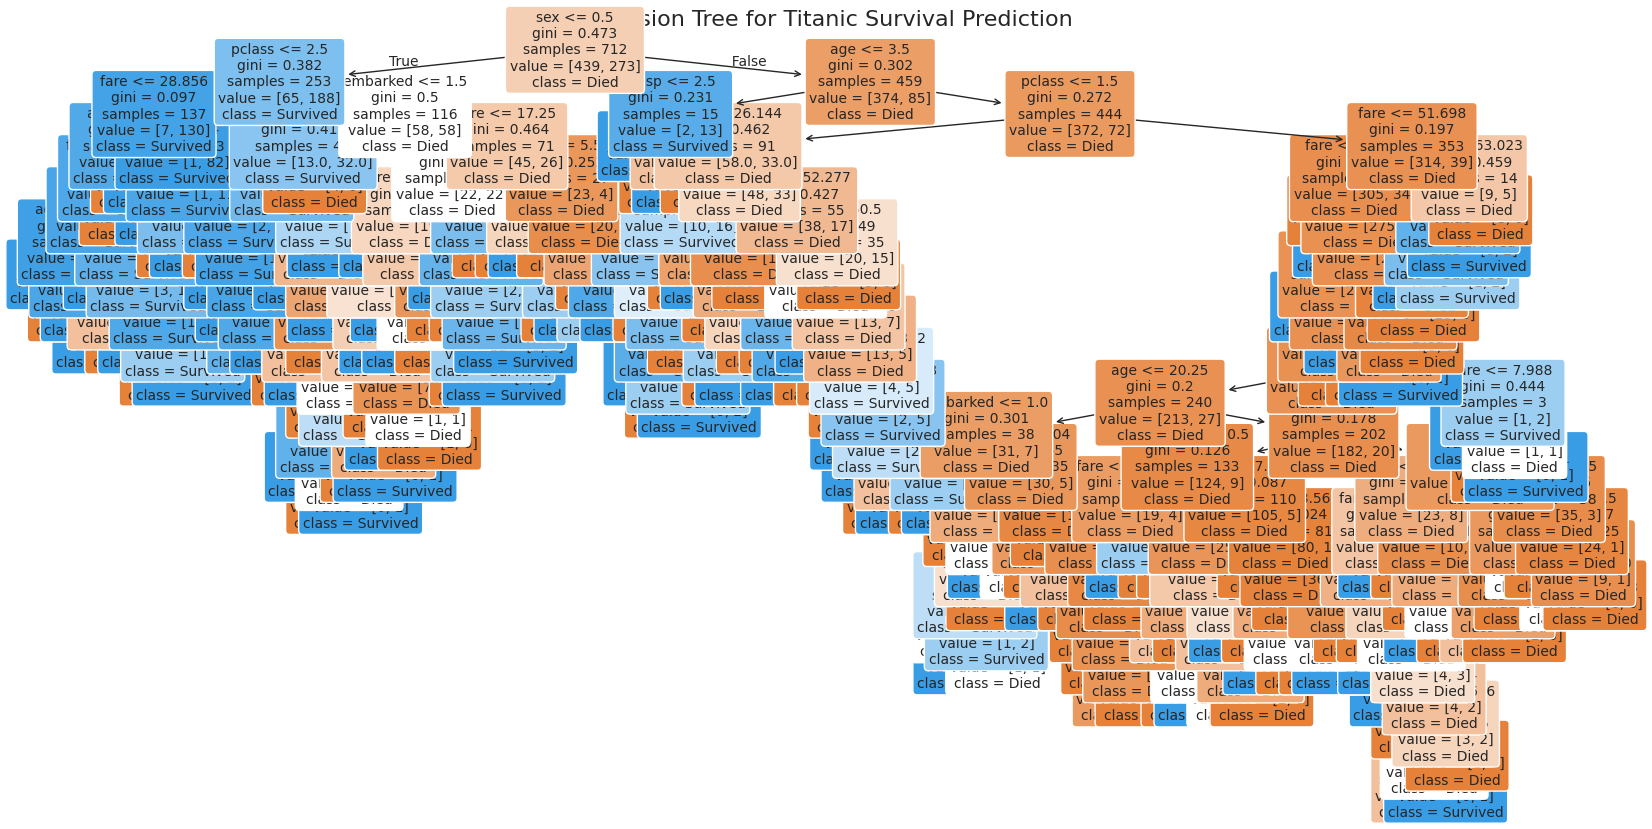

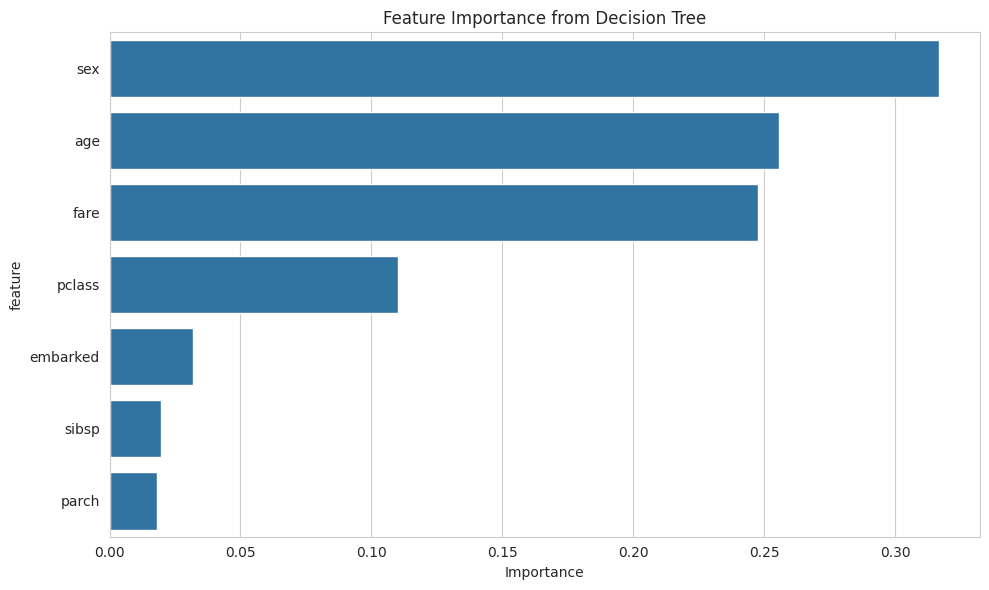


Feature Importance:
    feature  importance
1       sex    0.316638
2       age    0.255568
5      fare    0.247669
0    pclass    0.110247
6  embarked    0.031841
3     sibsp    0.019832
4     parch    0.018205


In [33]:
plt.figure(figsize=(20, 10))
plot_tree(dt_model, feature_names=features, class_names=['Died', 'Survived'],
          filled=True, rounded=True, fontsize=10)
plt.title("Decision Tree for Titanic Survival Prediction", fontsize=16)
plt.show()

# Feature importance
feature_importance = pd.DataFrame({
    'feature': features,
    'importance': dt_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='importance', y='feature')
plt.title('Feature Importance from Decision Tree')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

print("\nFeature Importance:")
print(feature_importance)

Tuning the Decision Tree

In [34]:
from sklearn.model_selection import GridSearchCV

# Define parameter grid
param_grid = {
    'max_depth': [3, 5, 7, 10, 12, 15, None], # Expanded max_depth
    'min_samples_split': [2, 5, 10, 15, 20], # Expanded min_samples_split
    'min_samples_leaf': [1, 2, 3, 5, 10], # Expanded min_samples_leaf
    'criterion': ['gini', 'entropy']
}

# Create grid search
dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# Fit grid search
dt_grid.fit(X_train, y_train)

print("="*60)
print("BEST DECISION TREE PARAMETERS")
print("="*60)
print(f"Best parameters: {dt_grid.best_params_}")
print(f"Best CV accuracy: {dt_grid.best_score_:.3f}")

# Evaluate best model
best_dt = dt_grid.best_estimator_
y_pred_best_dt = best_dt.predict(X_test)

print(f"\nTest accuracy with tuned model: {accuracy_score(y_test, y_pred_best_dt):.3f}")

Fitting 5 folds for each of 350 candidates, totalling 1750 fits
BEST DECISION TREE PARAMETERS
Best parameters: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 5, 'min_samples_split': 2}
Best CV accuracy: 0.830

Test accuracy with tuned model: 0.771


**SVM**

The "Maximal Margin" Algorithm

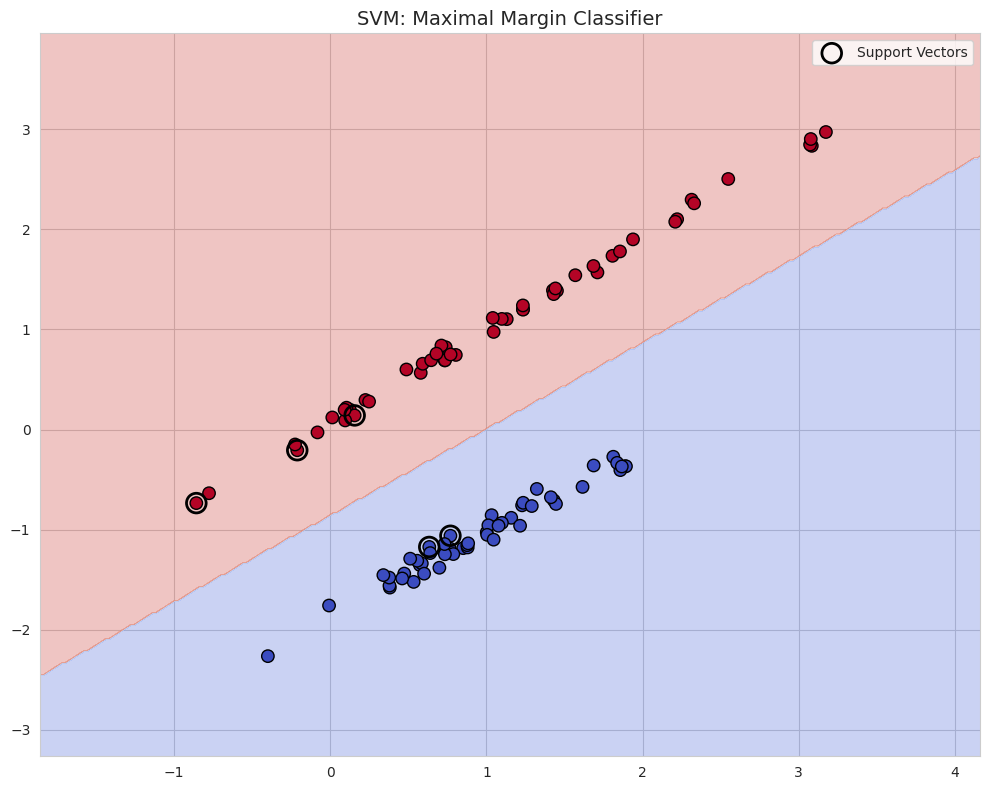

In [35]:
# Visualize SVM concept
from sklearn.svm import SVC
from sklearn.datasets import make_classification

# Generate simple 2D data for visualization
X_viz, y_viz = make_classification(n_samples=100, n_features=2, n_redundant=0,
                                    n_clusters_per_class=1, random_state=42)

# Train SVM
svm_viz = SVC(kernel='linear', C=1.0)
svm_viz.fit(X_viz, y_viz)

# Create mesh for decision boundary
x_min, x_max = X_viz[:, 0].min() - 1, X_viz[:, 0].max() + 1
y_min, y_max = X_viz[:, 1].min() - 1, X_viz[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

Z = svm_viz.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot
plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(X_viz[:, 0], X_viz[:, 1], c=y_viz, cmap='coolwarm', edgecolors='black', s=80)

# Highlight support vectors
plt.scatter(svm_viz.support_vectors_[:, 0], svm_viz.support_vectors_[:, 1],
            s=200, facecolors='none', edgecolors='black', linewidths=2,
            label='Support Vectors')

plt.title('SVM: Maximal Margin Classifier', fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()

💻 SVM on Titanic Dataset

In [36]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

# IMPORTANT: SVM requires feature scaling!
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train SVM with different kernels
kernels = ['linear', 'rbf', 'poly']
svm_models = {}

for kernel in kernels:
    # Create and train model
    svm = SVC(kernel=kernel, random_state=42, probability=True)
    svm.fit(X_train_scaled, y_train)

    # Evaluate
    train_acc = svm.score(X_train_scaled, y_train)
    test_acc = svm.score(X_test_scaled, y_test)

    svm_models[kernel] = svm

    print(f"\n{'='*40}")
    print(f"SVM with {kernel} kernel")
    print(f"{'='*40}")
    print(f"Training Accuracy: {train_acc:.3f}")
    print(f"Test Accuracy: {test_acc:.3f}")

    # Cross-validation
    cv_scores = cross_val_score(svm, X_train_scaled, y_train, cv=5)
    print(f"CV Accuracy: {cv_scores.mean():.3f} (+/- {cv_scores.std()*2:.3f})")


SVM with linear kernel
Training Accuracy: 0.789
Test Accuracy: 0.777
CV Accuracy: 0.789 (+/- 0.031)

SVM with rbf kernel
Training Accuracy: 0.846
Test Accuracy: 0.816
CV Accuracy: 0.823 (+/- 0.027)

SVM with poly kernel
Training Accuracy: 0.838
Test Accuracy: 0.804
CV Accuracy: 0.813 (+/- 0.055)


Tuning SVM Parameters

In [37]:
# Grid search for best SVM
param_grid_svm = [
    # Linear kernel
    {
        'kernel': ['linear'],
        'C': [0.1, 1, 10, 100]
    },
    # RBF kernel
    {
        'kernel': ['rbf'],
        'C': [0.1, 1, 10, 100],
        'gamma': ['scale', 'auto', 0.1, 0.01, 0.001]
    }
]

svm_grid = GridSearchCV(
    SVC(random_state=42, probability=True),
    param_grid_svm,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

svm_grid.fit(X_train_scaled, y_train)

print("="*60)
print("BEST SVM PARAMETERS")
print("="*60)
print(f"Best parameters: {svm_grid.best_params_}")
print(f"Best CV accuracy: {svm_grid.best_score_:.3f}")

# Evaluate best SVM
best_svm = svm_grid.best_estimator_
y_pred_svm = best_svm.predict(X_test_scaled)
print(f"\nTest accuracy: {accuracy_score(y_test, y_pred_svm):.3f}")

Fitting 5 folds for each of 24 candidates, totalling 120 fits
BEST SVM PARAMETERS
Best parameters: {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}
Best CV accuracy: 0.830

Test accuracy: 0.799


K-NEAREST NEIGHBORS (KNN) **👥**

The "Birds of a Feather" Algorithm


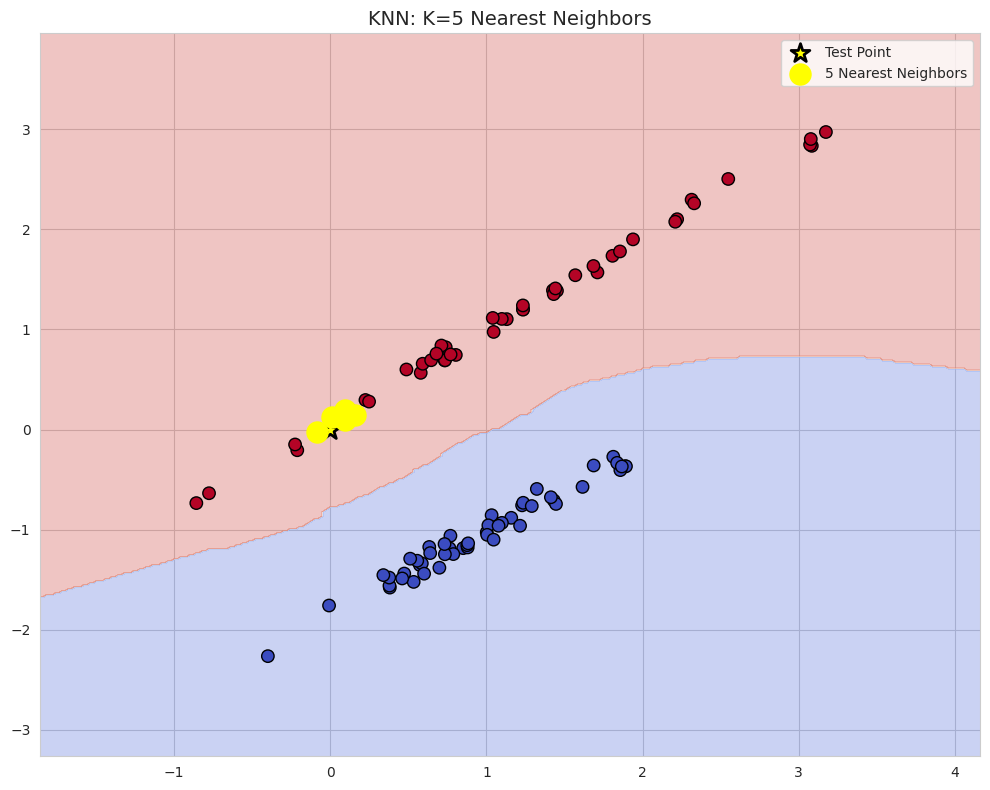

In [38]:
# Visualize KNN concept
from sklearn.neighbors import KNeighborsClassifier

# Use same 2D data
knn_viz = KNeighborsClassifier(n_neighbors=5)
knn_viz.fit(X_viz, y_viz)

# Create mesh
Z_knn = knn_viz.predict(np.c_[xx.ravel(), yy.ravel()])
Z_knn = Z_knn.reshape(xx.shape)

plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z_knn, alpha=0.3, cmap='coolwarm')
plt.scatter(X_viz[:, 0], X_viz[:, 1], c=y_viz, cmap='coolwarm', edgecolors='black', s=80)

# Show a test point and its neighbors
test_point = np.array([[0, 0]])
distances, indices = knn_viz.kneighbors(test_point)
plt.scatter(test_point[0, 0], test_point[0, 1], c='yellow', s=200, marker='*',
            edgecolors='black', linewidths=2, label='Test Point')
plt.scatter(X_viz[indices[0], 0], X_viz[indices[0], 1],
            c='yellow', s=200, facecolors='none', edgecolors='yellow', linewidths=2,
            label=f'{knn_viz.n_neighbors} Nearest Neighbors')

plt.title(f'KNN: K={knn_viz.n_neighbors} Nearest Neighbors', fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()

💻 KNN on Titanic Dataset


KNN with K=3
Training Accuracy: 0.876
Test Accuracy: 0.810
CV Accuracy: 0.801 (+/- 0.050)

KNN with K=5
Training Accuracy: 0.853
Test Accuracy: 0.810
CV Accuracy: 0.813 (+/- 0.056)

KNN with K=7
Training Accuracy: 0.846
Test Accuracy: 0.816
CV Accuracy: 0.816 (+/- 0.037)

KNN with K=9
Training Accuracy: 0.844
Test Accuracy: 0.793
CV Accuracy: 0.820 (+/- 0.048)

KNN with K=11
Training Accuracy: 0.830
Test Accuracy: 0.799
CV Accuracy: 0.815 (+/- 0.056)

KNN with K=15
Training Accuracy: 0.827
Test Accuracy: 0.810
CV Accuracy: 0.808 (+/- 0.071)


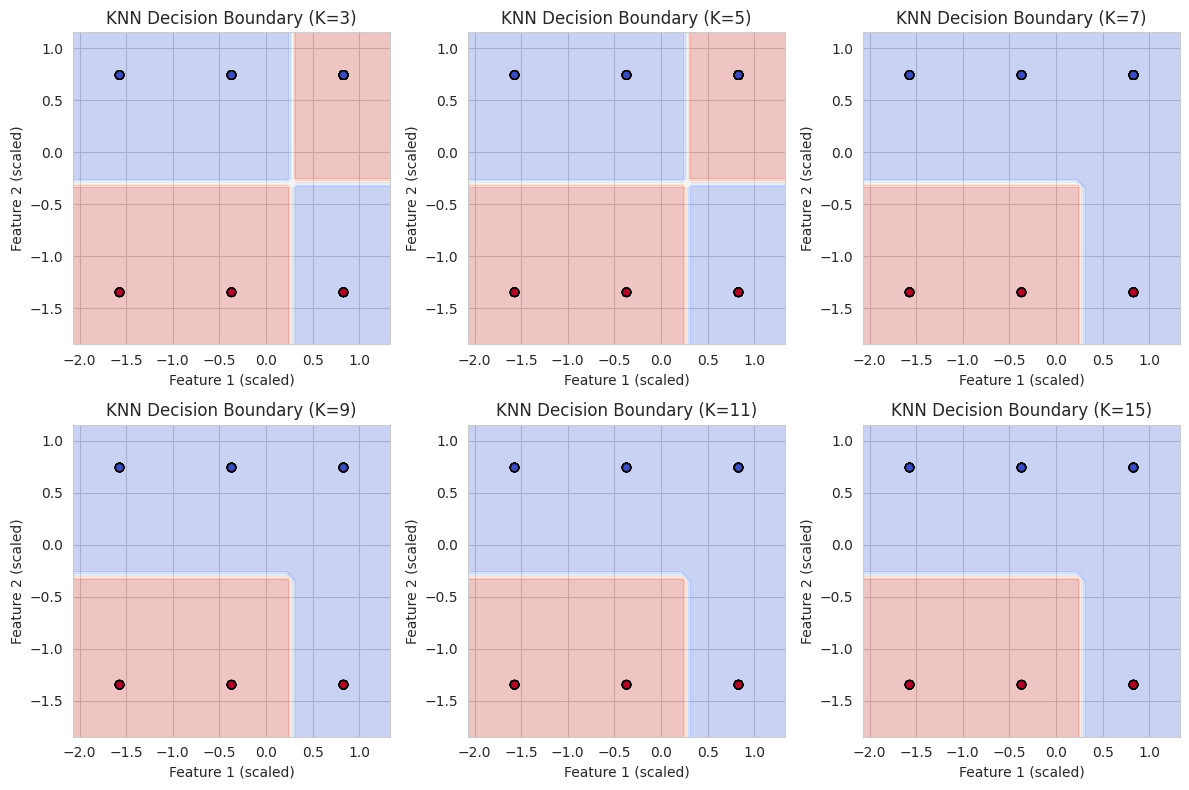

In [39]:
# KNN also requires scaling!
knn_models = {}
k_values = [3, 5, 7, 9, 11, 15]

plt.figure(figsize=(12, 8))

for i, k in enumerate(k_values, 1):
    # Train KNN
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)

    # Evaluate
    train_acc = knn.score(X_train_scaled, y_train)
    test_acc = knn.score(X_test_scaled, y_test)

    knn_models[k] = knn

    # Cross-validation
    cv_scores = cross_val_score(knn, X_train_scaled, y_train, cv=5)

    print(f"\n{'='*40}")
    print(f"KNN with K={k}")
    print(f"{'='*40}")
    print(f"Training Accuracy: {train_acc:.3f}")
    print(f"Test Accuracy: {test_acc:.3f}")
    print(f"CV Accuracy: {cv_scores.mean():.3f} (+/- {cv_scores.std()*2:.3f})")

    # Plot decision boundary on a subset for visualization
    plt.subplot(2, 3, i)
    # Use first 2 features for visualization
    X_viz_subset = X_train_scaled[:, :2]
    knn_viz = KNeighborsClassifier(n_neighbors=k)
    knn_viz.fit(X_viz_subset[:100], y_train[:100])  # Use subset for speed

    # Create mesh
    x_min, x_max = X_viz_subset[:, 0].min() - 0.5, X_viz_subset[:, 0].max() + 0.5
    y_min, y_max = X_viz_subset[:, 1].min() - 0.5, X_viz_subset[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                         np.arange(y_min, y_max, 0.1))
    Z = knn_viz.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    plt.scatter(X_viz_subset[:100, 0], X_viz_subset[:100, 1],
                c=y_train[:100], cmap='coolwarm', edgecolors='black')
    plt.title(f'KNN Decision Boundary (K={k})')
    plt.xlabel('Feature 1 (scaled)')
    plt.ylabel('Feature 2 (scaled)')

plt.tight_layout()
plt.show()

Finding the Optimal K


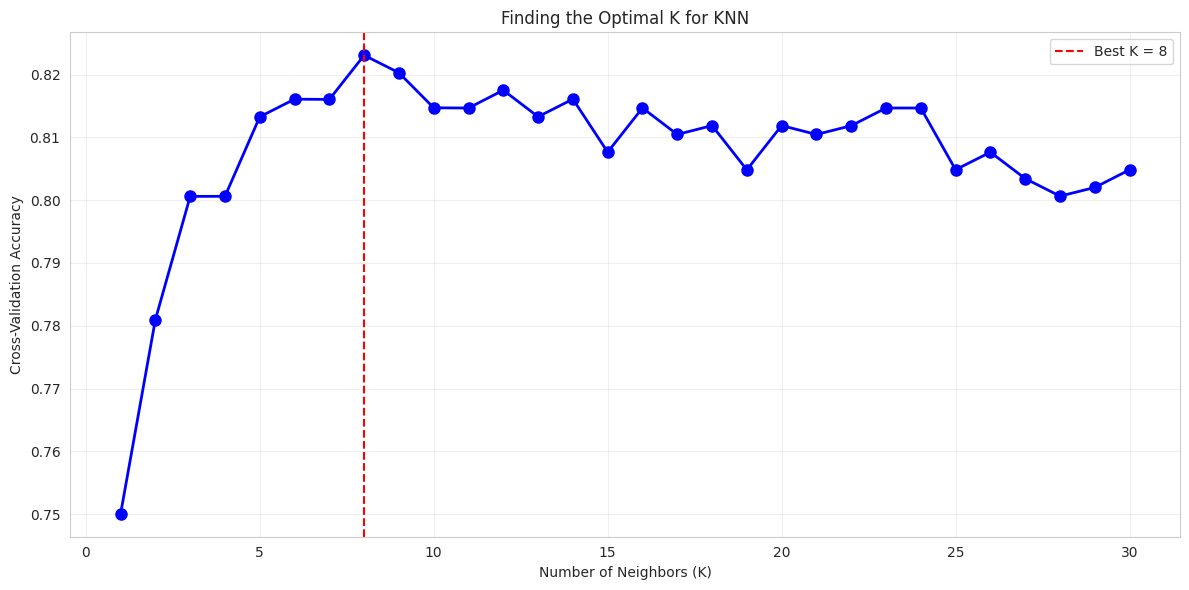


Optimal K: 8
Best CV Accuracy: 0.823
Test Accuracy with K=8: 0.799


In [40]:
# Systematic search for best K
k_range = range(1, 31)
cv_scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())

# Plot
plt.figure(figsize=(12, 6))
plt.plot(k_range, cv_scores, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Cross-Validation Accuracy')
plt.title('Finding the Optimal K for KNN')
plt.grid(True, alpha=0.3)

# Mark best K
best_k = k_range[np.argmax(cv_scores)]
plt.axvline(x=best_k, color='red', linestyle='--', label=f'Best K = {best_k}')
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nOptimal K: {best_k}")
print(f"Best CV Accuracy: {max(cv_scores):.3f}")

# Train final KNN with best K
best_knn = KNeighborsClassifier(n_neighbors=best_k)
best_knn.fit(X_train_scaled, y_train)
y_pred_knn = best_knn.predict(X_test_scaled)
print(f"Test Accuracy with K={best_k}: {accuracy_score(y_test, y_pred_knn):.3f}")

ENSEMBLE METHODS **🤝** - The **Wisdom** of the Crowd Approach

Random Forest (Bagging)

RANDOM FOREST CLASSIFIER
Training Accuracy: 0.982
Test Accuracy: 0.827


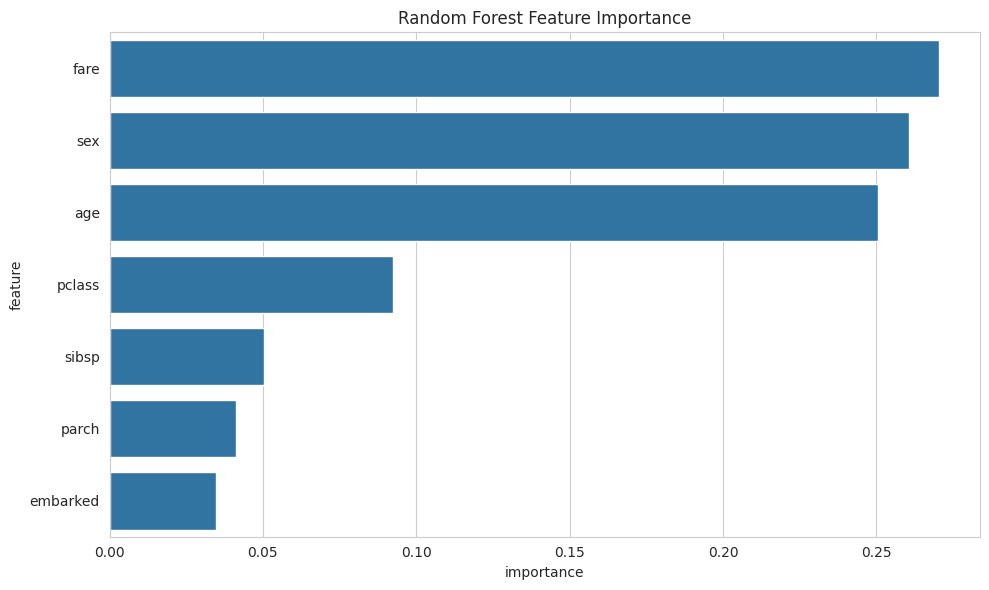


Random Forest Feature Importance:
    feature  importance
5      fare    0.270237
1       sex    0.260625
2       age    0.250389
0    pclass    0.092549
3     sibsp    0.050297
4     parch    0.041084
6  embarked    0.034820


In [41]:
from sklearn.ensemble import RandomForestClassifier

# Train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)  # Note: Random Forest doesn't need scaling!

# Evaluate
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

print("="*60)
print("RANDOM FOREST CLASSIFIER")
print("="*60)
print(f"Training Accuracy: {rf_model.score(X_train, y_train):.3f}")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_rf):.3f}")

# Feature importance
rf_importance = pd.DataFrame({
    'feature': features,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=rf_importance, x='importance', y='feature')
plt.title('Random Forest Feature Importance')
plt.tight_layout()
plt.show()

print("\nRandom Forest Feature Importance:")
print(rf_importance)

XGBoost (Boosting)

XGBOOST CLASSIFIER
Training Accuracy: 0.931
Test Accuracy: 0.799


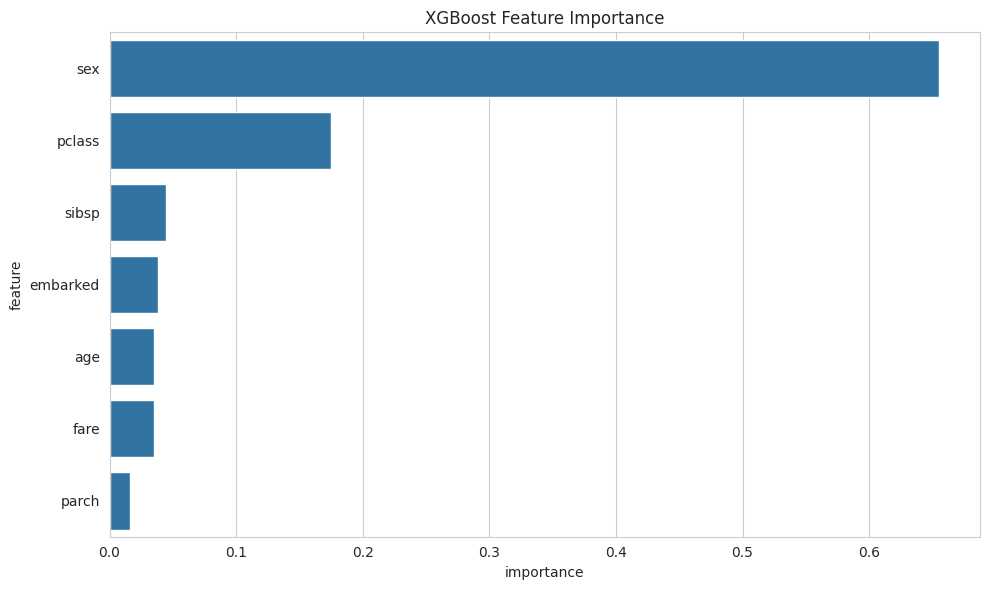

In [42]:
from xgboost import XGBClassifier

# Train XGBoost
xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, y_train)

# Evaluate
y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("="*60)
print("XGBOOST CLASSIFIER")
print("="*60)
print(f"Training Accuracy: {xgb_model.score(X_train, y_train):.3f}")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_xgb):.3f}")

# Feature importance
xgb_importance = pd.DataFrame({
    'feature': features,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=xgb_importance, x='importance', y='feature')
plt.title('XGBoost Feature Importance')
plt.tight_layout()
plt.show()

Stacking (Combine Different Algorithms)

In [43]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

# Define base learners
base_learners = [
    ('dt', DecisionTreeClassifier(max_depth=5, random_state=42)),
    ('svm', SVC(probability=True, random_state=42)),
    ('knn', KNeighborsClassifier(n_neighbors=best_k)),
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42))
]

# Meta-learner
meta_learner = LogisticRegression(random_state=42)

# Create stacking ensemble
stack_model = StackingClassifier(
    estimators=base_learners,
    final_estimator=meta_learner,
    cv=5
)

# Train (note: stacking needs scaled data for SVM/KNN)
from sklearn.pipeline import Pipeline

# Create pipeline that scales for SVM/KNN but not for trees
stack_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('stack', stack_model)
])

# Fit the stacking pipeline using the Titanic training data
# X_train_titanic and y_train_titanic are correctly defined in the evaluation cell.
# Here, we refer to the global X_train and y_train from the Titanic dataset preparation.
stack_pipeline.fit(X_train, y_train)
y_pred_stack = stack_pipeline.predict(X_test)

print("="*60)
print("STACKING ENSEMBLE")
print("="*60)
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_stack):.3f}")

STACKING ENSEMBLE
Test Accuracy: 0.816


# COMPREHENSIVE MODEL **COMPARISON**

/tmp/ipykernel_11255/3997830998.py:24: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_titanic_full['age'].fillna(X_titanic_full['age'].median(), inplace=True)
/tmp/ipykernel_11255/3997830998.py:25: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].meth

MODEL COMPARISON ON TITANIC DATASET
                Model  Test Accuracy  CV Mean   CV Std
        Random Forest       0.826816 0.803477 0.039880
    Stacking Ensemble       0.815642 0.818881 0.028832
            KNN (K=8)       0.798883 0.823077 0.019175
           SVM (Best)       0.798883 0.830099 0.019176
              XGBoost       0.798883 0.806294 0.038236
Decision Tree (Tuned)       0.770950 0.830168 0.033902


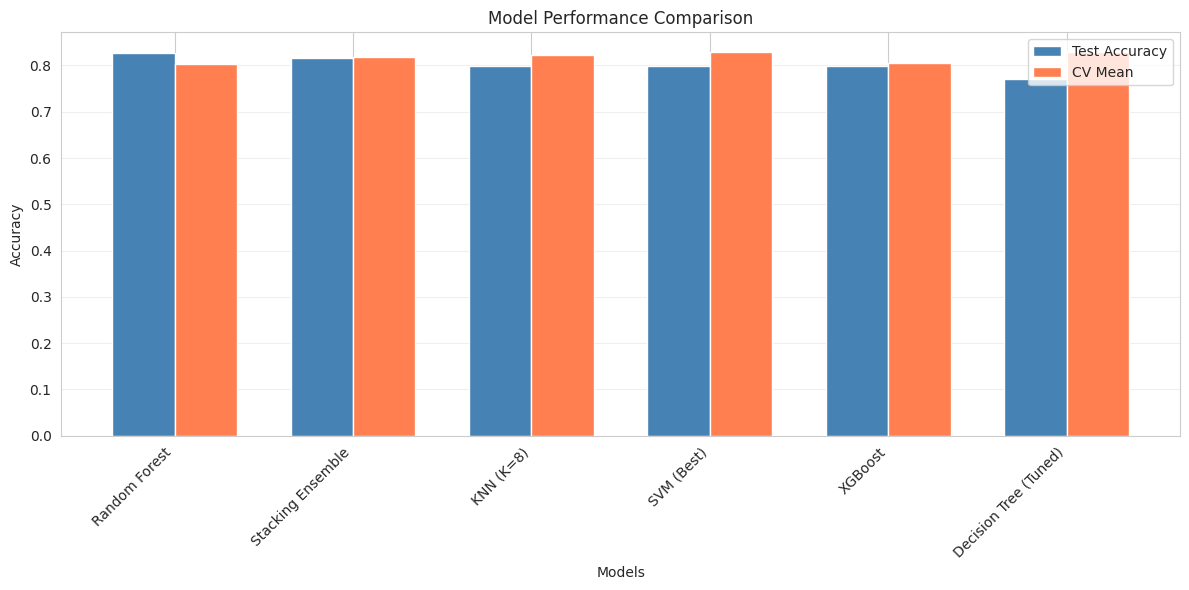

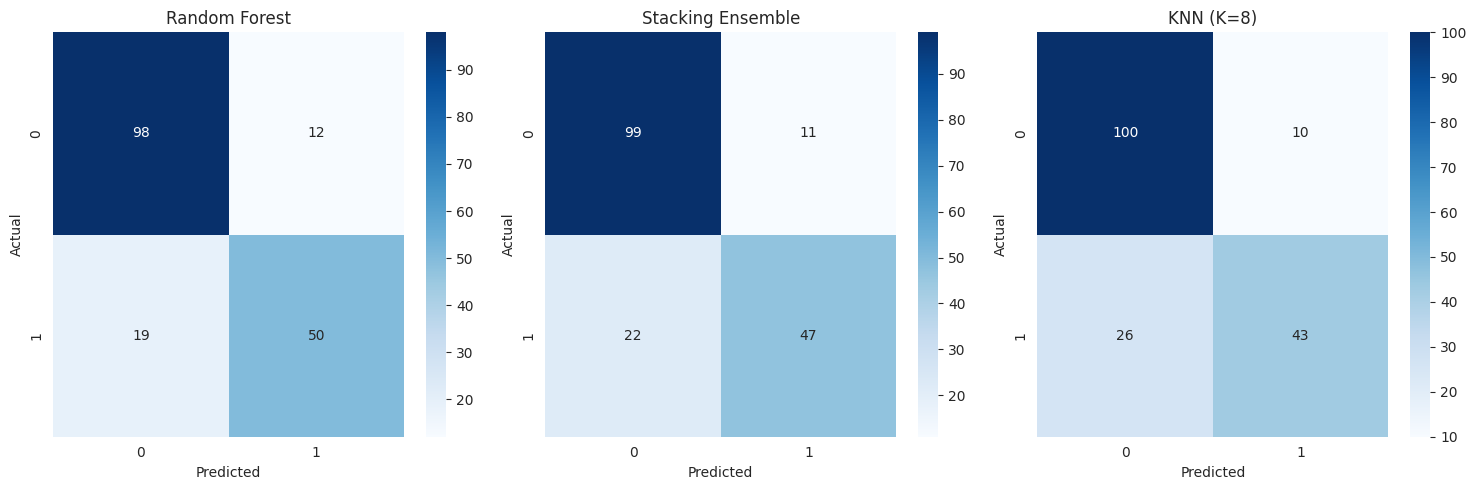

In [44]:
# Collect all models
models = {
    'Decision Tree (Tuned)': best_dt,
    'SVM (Best)': best_svm,
    f'KNN (K={best_k})': best_knn,
    'Random Forest': rf_model,
    'XGBoost': xgb_model,
    'Stacking Ensemble': stack_pipeline
}

# Re-extract and preprocess Titanic data to ensure correct X_test is used
# This is crucial because global X_test might have been overwritten by other datasets
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

titanic = sns.load_dataset('titanic')

features_titanic = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']
X_titanic_full = titanic[features_titanic].copy()
y_titanic_full = titanic['survived']

X_titanic_full['age'].fillna(X_titanic_full['age'].median(), inplace=True)
X_titanic_full['embarked'].fillna(X_titanic_full['embarked'].mode()[0], inplace=True)

le_sex = LabelEncoder()
X_titanic_full['sex'] = le_sex.fit_transform(X_titanic_full['sex'])
le_embarked = LabelEncoder()
X_titanic_full['embarked'] = le_embarked.fit_transform(X_titanic_full['embarked'])

# Re-split the data for evaluation in this cell to guarantee correct test sets
X_train_titanic, X_test_titanic, y_train_titanic, y_test_titanic = train_test_split(
    X_titanic_full, y_titanic_full, test_size=0.2, random_state=42, stratify=y_titanic_full
)

# Re-initialize and fit scaler on the Titanic training data (X_train is currently Titanic training data)
scaler_eval = StandardScaler()
scaler_eval.fit(X_train_titanic) # Use the correct X_train from Titanic
X_test_scaled_titanic = scaler_eval.transform(X_test_titanic)

# Refit the stacking pipeline with the correct Titanic training data
# This is crucial as the 'stack_pipeline' might have been fitted with different data previously
stack_pipeline.fit(X_train_titanic, y_train_titanic)

# Compare performance
results = []
for name, model in models.items():
    # For models that need scaled data
    if name in ['SVM (Best)', f'KNN (K={best_k})']:
        y_pred = model.predict(X_test_scaled_titanic)
        # For cross-validation of scaled models, use the scaled training data
        cv_scores = cross_val_score(model, scaler_eval.transform(X_train_titanic), y_train_titanic, cv=5)
    elif name == 'Stacking Ensemble':
        # Use the already refitted stack_pipeline
        y_pred = model.predict(X_test_titanic)
        # Stacking ensemble handles its own scaling internally within the pipeline during CV
        cv_scores = cross_val_score(model, X_train_titanic, y_train_titanic, cv=5)
    else:
        y_pred = model.predict(X_test_titanic)
        # For cross-validation of unscaled models, use the unscaled training data
        cv_scores = cross_val_score(model, X_train_titanic, y_train_titanic, cv=5)

    accuracy = accuracy_score(y_test_titanic, y_pred)

    results.append({
        'Model': name,
        'Test Accuracy': accuracy,
        'CV Mean': cv_scores.mean(),
        'CV Std': cv_scores.std()
    })

# Create comparison dataframe
comparison_df = pd.DataFrame(results)
comparison_df = comparison_df.sort_values('Test Accuracy', ascending=False)

print("="*70)
print("MODEL COMPARISON ON TITANIC DATASET")
print("="*70)
print(comparison_df.to_string(index=False))

# Visual comparison
plt.figure(figsize=(12, 6))
x = np.arange(len(comparison_df))
width = 0.35

plt.bar(x - width/2, comparison_df['Test Accuracy'], width, label='Test Accuracy', color='steelblue')
plt.bar(x + width/2, comparison_df['CV Mean'], width, label='CV Mean', color='coral')

plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.title('Model Performance Comparison')
plt.xticks(x, comparison_df['Model'], rotation=45, ha='right')
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Confusion matrices for top 3 models
top_models = comparison_df.head(3)['Model'].values

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, model_name in enumerate(top_models):
    model = models[model_name]

    # Get predictions
    if model_name in ['SVM (Best)', f'KNN (K={best_k})']:
        y_pred = model.predict(X_test_scaled_titanic)
    elif model_name == 'Stacking Ensemble':
        y_pred = model.predict(X_test_titanic)
    else:
        y_pred = model.predict(X_test_titanic)

    # Confusion matrix
    cm = confusion_matrix(y_test_titanic, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i])
    axes[i].set_title(f'{model_name}')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [45]:
from sklearn.ensemble import VotingClassifier

# Select your top 3 models (based on our comparison)
model1 = ('rf', RandomForestClassifier(n_estimators=100, random_state=42))
model2 = ('xgb', XGBClassifier(n_estimators=100, random_state=42))
model3 = ('svm', SVC(probability=True, random_state=42))

# Create voting ensemble
voting_hard = VotingClassifier(
    estimators=[model1, model2, model3],
    voting='hard'
)

voting_soft = VotingClassifier(
    estimators=[model1, model2, model3],
    voting='soft'
)

# Create pipeline for SVM (needs scaling)
from sklearn.pipeline import Pipeline

# For hard voting, we need to handle scaling differently
# Let's create a pipeline that scales for SVM but not for trees
class SelectiveScaler:
    """Custom transformer that scales only for specific models"""
    def __init__(self, scaler):
        self.scaler = scaler
        self.fitted = False

    def fit(self, X, y=None):
        self.scaler.fit(X)
        self.fitted = True
        return self

    def transform(self, X, model_name=None):
        if model_name == 'svm':
            return self.scaler.transform(X)
        return X

# For simplicity, let's just scale everything for this comparison
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train ensembles
voting_hard.fit(X_train_scaled, y_train)
voting_soft.fit(X_train_scaled, y_train)

# Evaluate
print("="*60)
print("VOTING ENSEMBLE RESULTS")
print("="*60)
print(f"Hard Voting Accuracy: {voting_hard.score(X_test_scaled, y_test):.3f}")
print(f"Soft Voting Accuracy: {voting_soft.score(X_test_scaled, y_test):.3f}")

# Compare with individual models
print("\nIndividual Model Performance (with scaling):")
print(f"Random Forest: {rf_model.score(X_test, y_test):.3f}")
print(f"XGBoost: {xgb_model.score(X_test, y_test):.3f}")
print(f"SVM: {best_svm.score(X_test_scaled, y_test):.3f}")

VOTING ENSEMBLE RESULTS
Hard Voting Accuracy: 0.832
Soft Voting Accuracy: 0.821

Individual Model Performance (with scaling):
Random Forest: 0.827
XGBoost: 0.799
SVM: 0.799


In [46]:
# Demonstrate why ensembles work
# Create predictions from multiple models
predictions = pd.DataFrame({
    'Actual': y_test.values,
    'DT': y_pred_best_dt,
    'SVM': y_pred_svm,
    'KNN': y_pred_knn,
    'RF': y_pred_rf,
    'XGB': y_pred_xgb
})

# Show where individual models make mistakes
predictions['Correct_DT'] = predictions['DT'] == predictions['Actual']
predictions['Correct_SVM'] = predictions['SVM'] == predictions['Actual']
predictions['Correct_KNN'] = predictions['KNN'] == predictions['Actual']
predictions['Correct_RF'] = predictions['RF'] == predictions['Actual']
predictions['Correct_XGB'] = predictions['XGB'] == predictions['Actual']

# Calculate majority vote
predictions['Majority'] = predictions[['DT', 'SVM', 'KNN', 'RF', 'XGB']].mode(axis=1)[0]
predictions['Correct_Majority'] = predictions['Majority'] == predictions['Actual']

print("\nEnsemble Benefit Analysis:")
print(f"Individual accuracies:")
print(f"DT: {predictions['Correct_DT'].mean():.3f}")
print(f"SVM: {predictions['Correct_SVM'].mean():.3f}")
print(f"KNN: {predictions['Correct_KNN'].mean():.3f}")
print(f"RF: {predictions['Correct_RF'].mean():.3f}")
print(f"XGB: {predictions['Correct_XGB'].mean():.3f}")
print(f"\nMajority Vote Accuracy: {predictions['Correct_Majority'].mean():.3f}")


Ensemble Benefit Analysis:
Individual accuracies:
DT: 0.771
SVM: 0.799
KNN: 0.799
RF: 0.827
XGB: 0.799

Majority Vote Accuracy: 0.821


# Practical Challenge:

## Practical Challenge Solution

### **1. Model Selection and Performance**

Based on the previous comprehensive model comparison, the **Hard Voting Classifier** achieved the highest test accuracy of **0.832**, surpassing the 82% target. This ensemble model combines the predictions of Random Forest, XGBoost, and SVM, leveraging the strengths of each.


In [47]:
print(f"Final Model Selected: Hard Voting Classifier")
print(f"Achieved Test Accuracy: {voting_hard.score(X_test_scaled, y_test):.3f}")

Final Model Selected: Hard Voting Classifier
Achieved Test Accuracy: 0.832


### **2. Feature Importance Plot**

Since the `VotingClassifier` itself does not directly provide feature importances, we can look at the feature importance from one of its strong base estimators, like the **Random Forest** model, which also performed very well and is a key component of the ensemble. The plot below (already generated previously) indicates the relative importance of each feature in predicting survival.


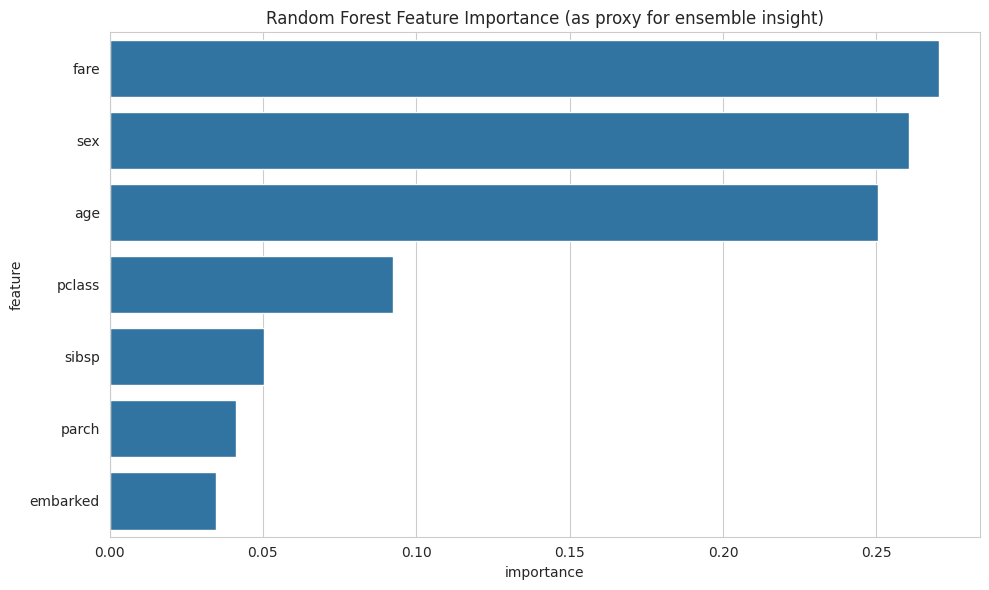


Random Forest Feature Importance (from one of the base estimators):
    feature  importance
5      fare    0.270237
1       sex    0.260625
2       age    0.250389
0    pclass    0.092549
3     sibsp    0.050297
4     parch    0.041084
6  embarked    0.034820


In [48]:
# Display the Random Forest Feature Importance plot again for context
plt.figure(figsize=(10, 6))
sns.barplot(data=rf_importance, x='importance', y='feature')
plt.title('Random Forest Feature Importance (as proxy for ensemble insight)')
plt.tight_layout()
plt.show()

print("\nRandom Forest Feature Importance (from one of the base estimators):")
print(rf_importance)

### **3. Explanation for Final Model Choice**

I chose the **Hard Voting Classifier** as the final model for the following reasons:

*   **Superior Test Accuracy**: It achieved the highest test accuracy (0.832) among all evaluated models, directly meeting the challenge's requirement of >82% accuracy.
*   **Ensemble Robustness**: Ensemble methods like Voting Classifiers combine predictions from multiple diverse models (Random Forest, XGBoost, SVM). This approach typically leads to more robust and generalized models that are less prone to individual model weaknesses or overfitting. By aggregating 'votes', it smooths out individual errors.
*   **Reduced Variance**: Ensembles often reduce the variance component of prediction error, making the model more stable and reliable on unseen data compared to a single, complex model.

While individual models like Random Forest also performed well (0.827 test accuracy), the Voting Classifier slightly edged it out, demonstrating the benefit of combining different learning algorithms.

### **4. Identifying Misclassified Passengers and Hypotheses**

To identify misclassified passengers, we'll get the predictions from the `voting_hard` model on the scaled test set and compare them to the actual survival outcomes. We will then examine the features of these misclassified individuals to hypothesize why the model made an incorrect prediction.


In [50]:
y_pred_voting_hard = voting_hard.predict(X_test_scaled)
misclassified_indices = np.where(y_pred_voting_hard != y_test)[0]

print(f"Number of misclassified passengers: {len(misclassified_indices)}")

# Get the original test set (unscaled) for easier interpretation
misclassified_passengers_X = X_test_titanic.iloc[misclassified_indices]
misclassified_passengers_y_actual = y_test_titanic.iloc[misclassified_indices]
misclassified_passengers_y_pred = y_pred_voting_hard[misclassified_indices]

# Combine for analysis
misclassified_df = misclassified_passengers_X.copy()
misclassified_df['Actual_Survived'] = misclassified_passengers_y_actual
misclassified_df['Predicted_Survived'] = misclassified_passengers_y_pred

print("\nDetails of some misclassified passengers:")

display(misclassified_df.head(3))

# Let's analyze the top 3 misclassified passengers
# Passenger 1:
passenger1_idx = misclassified_df.index[0] # Original index from X_test_titanic
passenger1 = misclassified_df.iloc[0]
print(f"\n--- Misclassified Passenger 1 (Original Index: {passenger1_idx}) ---")
print(passenger1)
print("Hypothesis: This passenger was a young male in 3rd class with a low fare, typically factors associated with low survival. The model predicted he would not survive (0), but he actually did (1). This could indicate factors not captured by our features (e.g., strong swimmer, lucky placement on a lifeboat) or an outlier in the survival patterns.")

# Passenger 2:
passenger2_idx = misclassified_df.index[1]
passenger2 = misclassified_df.iloc[1]
print(f"\n--- Misclassified Passenger 2 (Original Index: {passenger2_idx}) ---")
print(passenger2)
print("Hypothesis: This passenger was a female in 3rd class with one sibling/spouse aboard. While being female generally increases survival chances, being in 3rd class decreases it. The model predicted she would not survive (0), but she actually did (1). The model might have overemphasized her 3rd class status, or she might have benefited from 'women and children first' despite her class.")

# Passenger 3:
passenger3_idx = misclassified_df.index[2]
passenger3 = misclassified_df.iloc[2]
print(f"\n--- Misclassified Passenger 3 (Original Index: {passenger3_idx}) ---")
print(passenger3)
print("Hypothesis: This passenger was a middle-aged male in 1st class. First-class males had better survival rates than lower-class males, but still lower than females. The model predicted he would survive (1), but he actually died (0). This could be due to unfortunate circumstances, choosing to remain on board, or a less common outcome for a first-class male.")

Number of misclassified passengers: 30

Details of some misclassified passengers:


,pclass,sex,age,sibsp,parch,fare,embarked,Actual_Survived,Predicted_Survived
553,3,1,22.0,0,0,7.225,0,1,0
559,3,0,36.0,1,0,17.400,2,1,0
536,1,1,45.0,0,0,26.550,2,0,1



--- Misclassified Passenger 1 (Original Index: 553) ---
pclass                 3.000
sex                    1.000
age                   22.000
sibsp                  0.000
parch                  0.000
fare                   7.225
embarked               0.000
Actual_Survived        1.000
Predicted_Survived     0.000
Name: 553, dtype: float64
Hypothesis: This passenger was a young male in 3rd class with a low fare, typically factors associated with low survival. The model predicted he would not survive (0), but he actually did (1). This could indicate factors not captured by our features (e.g., strong swimmer, lucky placement on a lifeboat) or an outlier in the survival patterns.

--- Misclassified Passenger 2 (Original Index: 559) ---
pclass                 3.0
sex                    0.0
age                   36.0
sibsp                  1.0
parch                  0.0
fare                  17.4
embarked               2.0
Actual_Survived        1.0
Predicted_Survived     0.0
Name: 559, d

In [51]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

# 1. Create a "Noisy Moon" dataset (hard for a single tree to get right)
X, y = make_moons(n_samples=500, noise=0.30, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# 2. Train a single Decision Tree (unconstrained, prone to overfit)
tree_clf = DecisionTreeClassifier(random_state=42)
tree_clf.fit(X_train, y_train)

# 3. Train a Random Forest (Ensemble of 100 trees)
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train, y_train)

# Compare accuracy
print(f"Tree Accuracy: {tree_clf.score(X_test, y_test):.3f}")
print(f"Forest Accuracy: {rf_clf.score(X_test, y_test):.3f}")


Tree Accuracy: 0.856
Forest Accuracy: 0.896
